In [1]:
PATH_BioData = "../../../DATASETS/BioData_backup_alex/"

PATH_MBLs = PATH_BioData + "all_data_mbls.csv"
PATH_SEQ = PATH_BioData + "all_data_seq.csv"
PATH_labels = "all_ids_labeled.csv"

PATH_moondb = "../../datasets/uniprot_ids_moondb.csv"
PATH_moonprot3 = "../../datasets/moonprot3_uniprot_ids_list.csv"

In [2]:
import pandas as pd

# Load datasets
df_mbls = pd.read_csv(PATH_MBLs)
df_seq = pd.read_csv(PATH_SEQ)
df_labels = pd.read_csv(PATH_labels)

df_seq["seq_length"] = df_seq["sequence"].apply(len)
df_labels["accession_code"] = df_labels["uniprot_id"]
df_labels.drop(columns=["uniprot_id"], inplace=True)

In [3]:
# Display columns of each dataset
print(f"Columns in {PATH_MBLs} as df_mbls:")
print(df_mbls.columns)
print(f"Length: {len(df_mbls)}")
print(f"Unique Uniprot IDs: {len(df_mbls['accession_code'].unique())}")

print(f"\nColumns in {PATH_SEQ} as df_seq:")
print(df_seq.columns)
print(f"Length: {len(df_seq)}")
print(f"Unique Uniprot IDs: {len(df_seq['accession_code'].unique())}")

print(f"\nColumns in {PATH_labels} as df_labels:")
print(df_labels.columns)
print(f"Length: {len(df_labels)}")
print(f"Unique Uniprot IDs: {len(df_labels['accession_code'].unique())}")

Columns in ../../../DATASETS/BioData_backup_alex/all_data_mbls.csv as df_mbls:
Index(['accession_code', 'c_max_mbl', 'f_max_mbl', 'p_max_mbl'], dtype='object')
Length: 1323
Unique Uniprot IDs: 1323

Columns in ../../../DATASETS/BioData_backup_alex/all_data_seq.csv as df_seq:
Index(['accession_code', 'organism', 'sequence', 'seq_length'], dtype='object')
Length: 1453
Unique Uniprot IDs: 1453

Columns in all_ids_labeled.csv as df_labels:
Index(['class', 'accession_code'], dtype='object')
Length: 1470
Unique Uniprot IDs: 1470


In [4]:
accession_moonprot = pd.read_csv(PATH_moonprot3)
print(f"\nColumns in {PATH_moonprot3}:")
print(accession_moonprot.columns)
accession_moonprot["accession_code"] = accession_moonprot["UniProt IDs"]
accession_moonprot.drop(columns=["UniProt IDs"], inplace=True)

accession_moondb = pd.read_csv(PATH_moondb)
print(f"\nColumns in {PATH_moondb}:")
print(accession_moondb.columns)
accession_moondb["accession_code"] = accession_moondb["UniProt IDs"]
accession_moondb.drop(columns=["UniProt IDs"], inplace=True)


Columns in ../../datasets/moonprot3_uniprot_ids_list.csv:
Index(['UniProt IDs'], dtype='object')

Columns in ../../datasets/uniprot_ids_moondb.csv:
Index(['UniProt IDs'], dtype='object')


In [5]:
# Function to determine provenance with an additional category for proteins in both moondb and moonprot
def determine_provenance(df, accession_moonprot, accession_moondb):
    df["provenance"] = "previous_study"  # Default to "previous_study"
    in_moonprot = df["accession_code"].isin(accession_moonprot["accession_code"])
    in_moondb = df["accession_code"].isin(accession_moondb["accession_code"])
    
    # Assign "moondb_moonprot" if the protein is in both moondb and moonprot
    df.loc[in_moonprot & in_moondb, "provenance"] = "moondb_moonprot"
    # Assign "moonprot" if the protein is only in moonprot
    df.loc[in_moonprot & ~in_moondb, "provenance"] = "moonprot"
    # Assign "moondb" if the protein is only in moondb
    df.loc[in_moondb & ~in_moonprot, "provenance"] = "moondb"
    
    return df

# Apply the function to each DataFrame
df_mbls_provenance = determine_provenance(df_mbls, accession_moonprot, accession_moondb)
df_seq_provenance = determine_provenance(df_seq, accession_moonprot, accession_moondb)
df_labels_provenance = determine_provenance(df_labels, accession_moonprot, accession_moondb)

# Display provenance counts for each DataFrame
print("Provenance counts for df_mbls:")
print(df_mbls_provenance["provenance"].value_counts())
print("\n Total number of proteins in df_mbls:", len(df_mbls_provenance))

print("\nProvenance counts for df_seq:")
print(df_seq_provenance["provenance"].value_counts())
print("\n Total number of proteins in df_seq:", len(df_seq_provenance))

print("\nProvenance counts for df_labels:")
print(df_labels_provenance["provenance"].value_counts())
print("\n Total number of proteins in df_labels:", len(df_labels_provenance))

Provenance counts for df_mbls:
provenance
previous_study     689
moondb             306
moonprot           297
moondb_moonprot     31
Name: count, dtype: int64

 Total number of proteins in df_mbls: 1323

Provenance counts for df_seq:
provenance
previous_study     692
moonprot           410
moondb             318
moondb_moonprot     33
Name: count, dtype: int64

 Total number of proteins in df_seq: 1453

Provenance counts for df_labels:
provenance
previous_study     689
moonprot           430
moondb             318
moondb_moonprot     33
Name: count, dtype: int64

 Total number of proteins in df_labels: 1470


In [6]:
# Merge df_mbls with df_seq on 'accession_code'
merged_df = pd.merge(df_mbls, df_seq, on="accession_code", how="inner")

# Merge the result with df_labels on 'accession_code'
merged_df = pd.merge(merged_df, df_labels, on="accession_code", how="inner")

# Display the shape and columns of the merged dataset
print(f"Merged dataset shape: {merged_df.shape}")
print(f"Columns in merged dataset: {merged_df.columns}")

# Save the merged dataset to a CSV file
merged_df.to_csv("merged_dataset.csv", index=False)

Merged dataset shape: (1321, 11)
Columns in merged dataset: Index(['accession_code', 'c_max_mbl', 'f_max_mbl', 'p_max_mbl', 'provenance_x',
       'organism', 'sequence', 'seq_length', 'provenance_y', 'class',
       'provenance'],
      dtype='object')


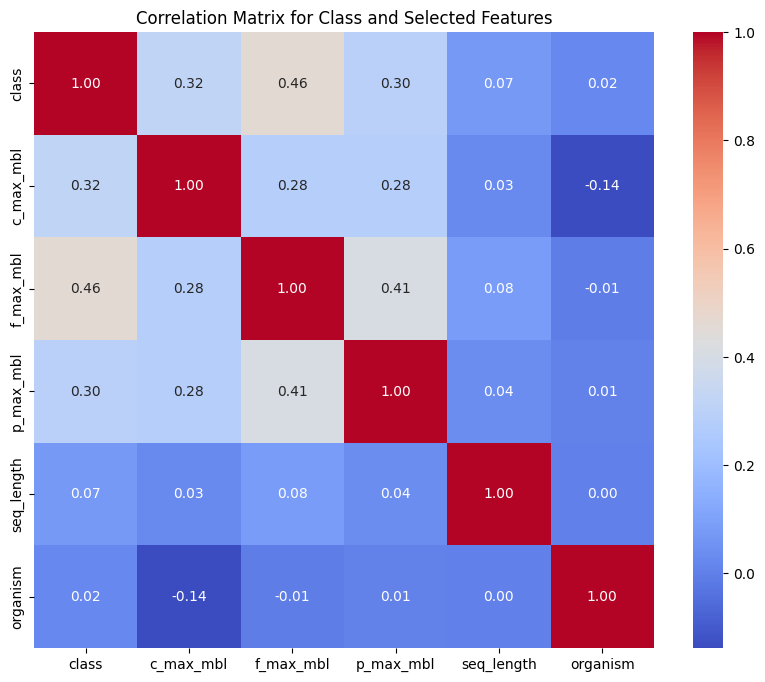

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select relevant columns
features = ['class', 'c_max_mbl', 'f_max_mbl', 'p_max_mbl', 'seq_length', 'organism']

# Encode 'organism' as numerical values
df_encoded = merged_df[features].copy()
df_encoded['organism'] = df_encoded['organism'].astype('category').cat.codes

# Filter the dataset to include only the relevant columns
df_corr = df_encoded[features]

# Compute the correlation matrix
correlation_matrix = df_corr.corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix for Class and Selected Features")
plt.show()

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

merged_df["organism"] = merged_df["organism"].str.replace(r"\s*\(.*?\)", "", regex=True)

# Group by organism and count the number of proteins
organism_counts = merged_df.groupby("organism").size().reset_index(name="protein_count")

# Filter organisms with at least 6 rows
organisms_at_least_6 = organism_counts[organism_counts["protein_count"] >= 6]

# Add class counts (True/False) for organisms with at least 6 rows
class_counts = (
    merged_df[merged_df["organism"].isin(organisms_at_least_6["organism"])]
    .groupby(["organism", "class"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
    .rename(columns={False: "False_count", True: "True_count"})
)

# Merge class counts with organism counts
organisms_at_least_6 = organisms_at_least_6.merge(class_counts, on="organism", how="left")

# Plot for organisms with at least 6 proteins
organisms_at_least_6 = organisms_at_least_6.sort_values(by="protein_count", ascending=False)

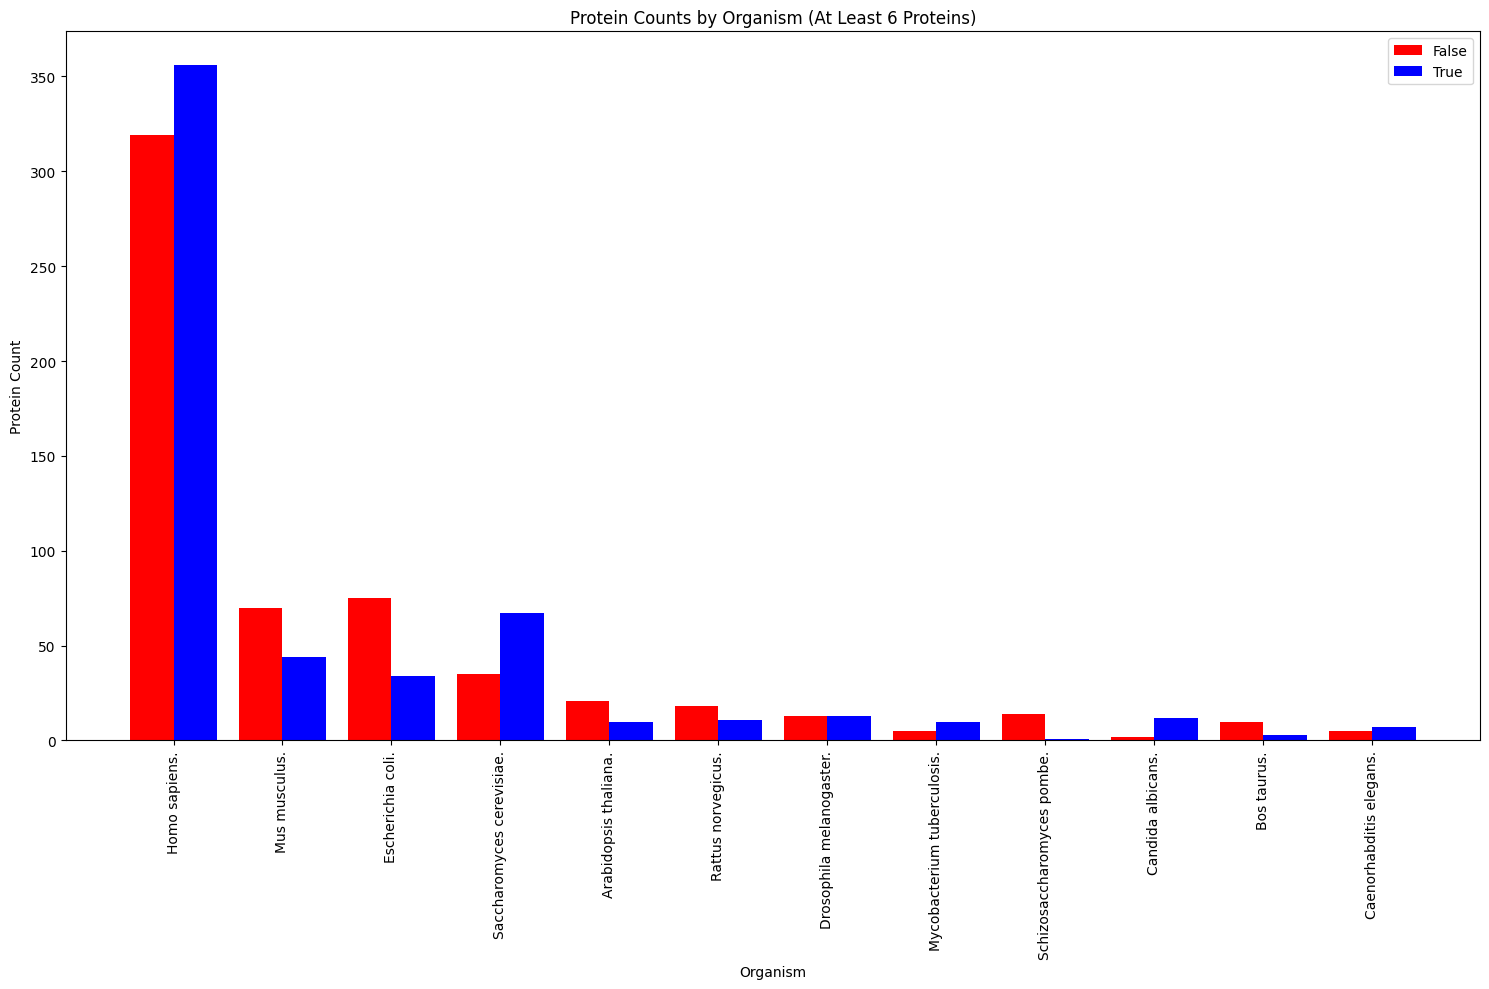

In [9]:
# Plotting
plt.figure(figsize=(15, 10))
x = np.arange(len(organisms_at_least_6))  # X-axis positions
width = 0.4  # Width of the bars

# Bars for False and True counts
plt.bar(x - width/2, organisms_at_least_6["False_count"], width, label="False", color="red")
plt.bar(x + width/2, organisms_at_least_6["True_count"], width, label="True", color="blue")

# Add labels and title
plt.xticks(x, organisms_at_least_6["organism"], rotation=90)
plt.xlabel("Organism")
plt.ylabel("Protein Count")
plt.title("Protein Counts by Organism (At Least 6 Proteins)")
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import re

# Select the 4 biggest organisms from organisms_at_least_6
top_4_organisms = organisms_at_least_6.head(4)["organism"]

# Filter the dataset for the top 4 organisms
df_top_4 = merged_df[merged_df["organism"].isin(top_4_organisms)]

# Remove rows with the greatest sequence length for each organism
max_seq_indices = df_top_4.groupby("organism")["seq_length"].idxmax()
df_top_4_filtered = df_top_4.drop(max_seq_indices)

# Create separate boxplots for each feature
features = ["c_max_mbl", "f_max_mbl", "p_max_mbl", "seq_length"]

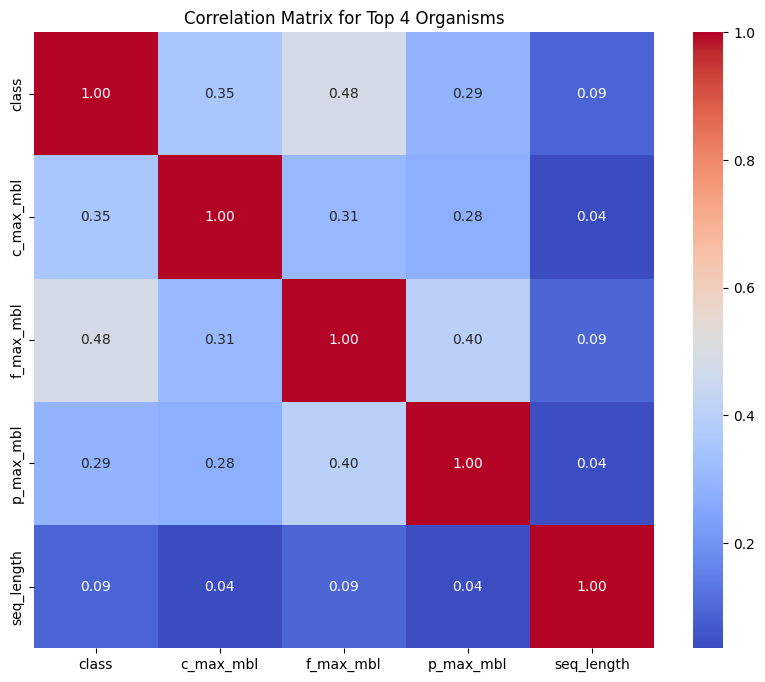

In [11]:
# Select relevant numerical columns for correlation, including 'class'
numerical_features = ["class", "c_max_mbl", "f_max_mbl", "p_max_mbl", "seq_length"]

# Compute the correlation matrix
correlation_matrix_top_4 = df_top_4[numerical_features].corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_top_4, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix for Top 4 Organisms")
plt.show()

                           organism_encoded  c_max_mbl  f_max_mbl  p_max_mbl  \
Escherichia coli.                       NaN   0.180480   0.396745   0.199218   
Homo sapiens.                           NaN   0.458924   0.552140   0.306733   
Mus musculus.                           NaN   0.180694   0.256373   0.194604   
Saccharomyces cerevisiae.               NaN   0.284032   0.305135   0.159433   
Top4 Combined                      0.101683   0.363455   0.483543   0.289449   

                           seq_length  
Escherichia coli.            0.030947  
Homo sapiens.                0.158370  
Mus musculus.                0.195237  
Saccharomyces cerevisiae.   -0.003970  
Top4 Combined                0.154534  


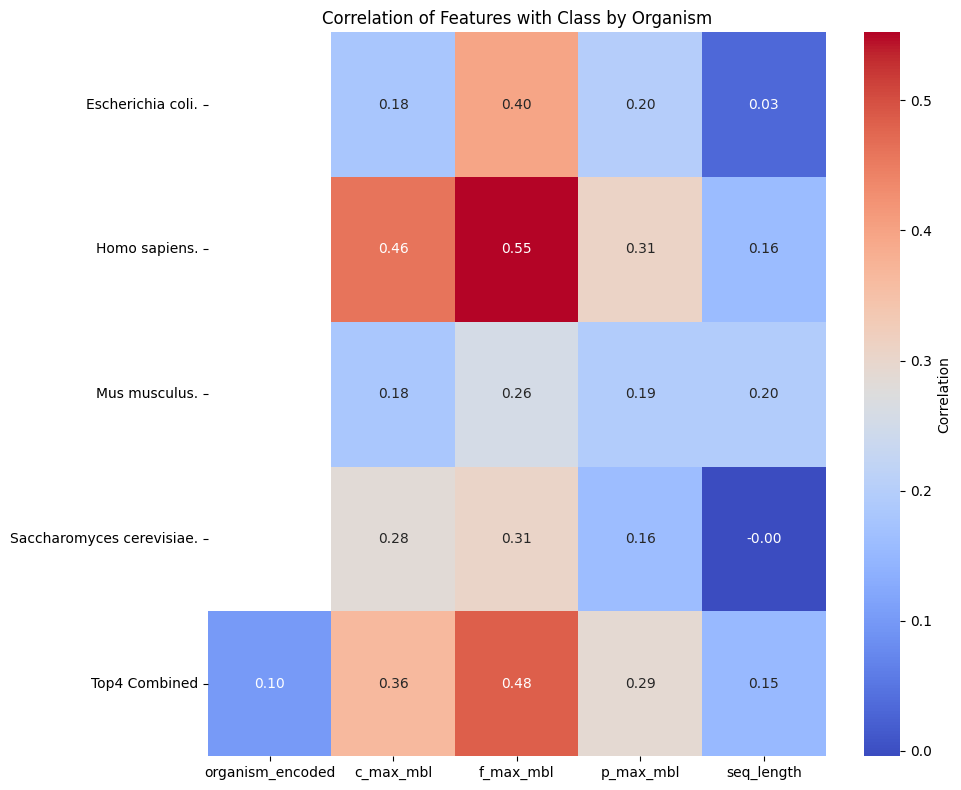

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Encode 'organism' as numerical values
df_top_4_filtered["organism_encoded"] = df_top_4_filtered["organism"].astype("category").cat.codes

# Select relevant numerical columns for correlation, including 'class' and 'organism_encoded'
numerical_features = ["class", "organism_encoded", "c_max_mbl", "f_max_mbl", "p_max_mbl", "seq_length"]

# Group the data by organism
grouped = df_top_4_filtered.groupby("organism")

# Create a dictionary to store correlations for each organism
correlation_dict = {}

# Compute the correlation of each feature with 'class' for each organism
for organism, group in grouped:
    correlations = group[numerical_features].corr()["class"].drop("class")  # Drop self-correlation
    correlation_dict[organism] = correlations

# Compute the combined correlation for all organisms
combined_correlation = df_top_4_filtered[numerical_features].corr()["class"].drop("class")
correlation_dict["Top4 Combined"] = combined_correlation

# Convert the dictionary to a DataFrame
correlation_table = pd.DataFrame(correlation_dict).T  # Transpose to have organisms as rows

# Display the table
print(correlation_table)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_table, annot=True, cmap="coolwarm", fmt=".2f", cbar_kws={'label': 'Correlation'})
plt.title("Correlation of Features with Class by Organism")

# Show the plot
plt.tight_layout()
plt.show()

In [13]:
# Find the index of the protein with the longest seq_length
max_seq_index = merged_df["seq_length"].idxmax()

# Drop the row with the longest seq_length
merged_df = merged_df.drop(index=max_seq_index)

# Display the updated DataFrame shape
print(f"Updated merged_df shape: {merged_df.shape}")

Updated merged_df shape: (1320, 11)


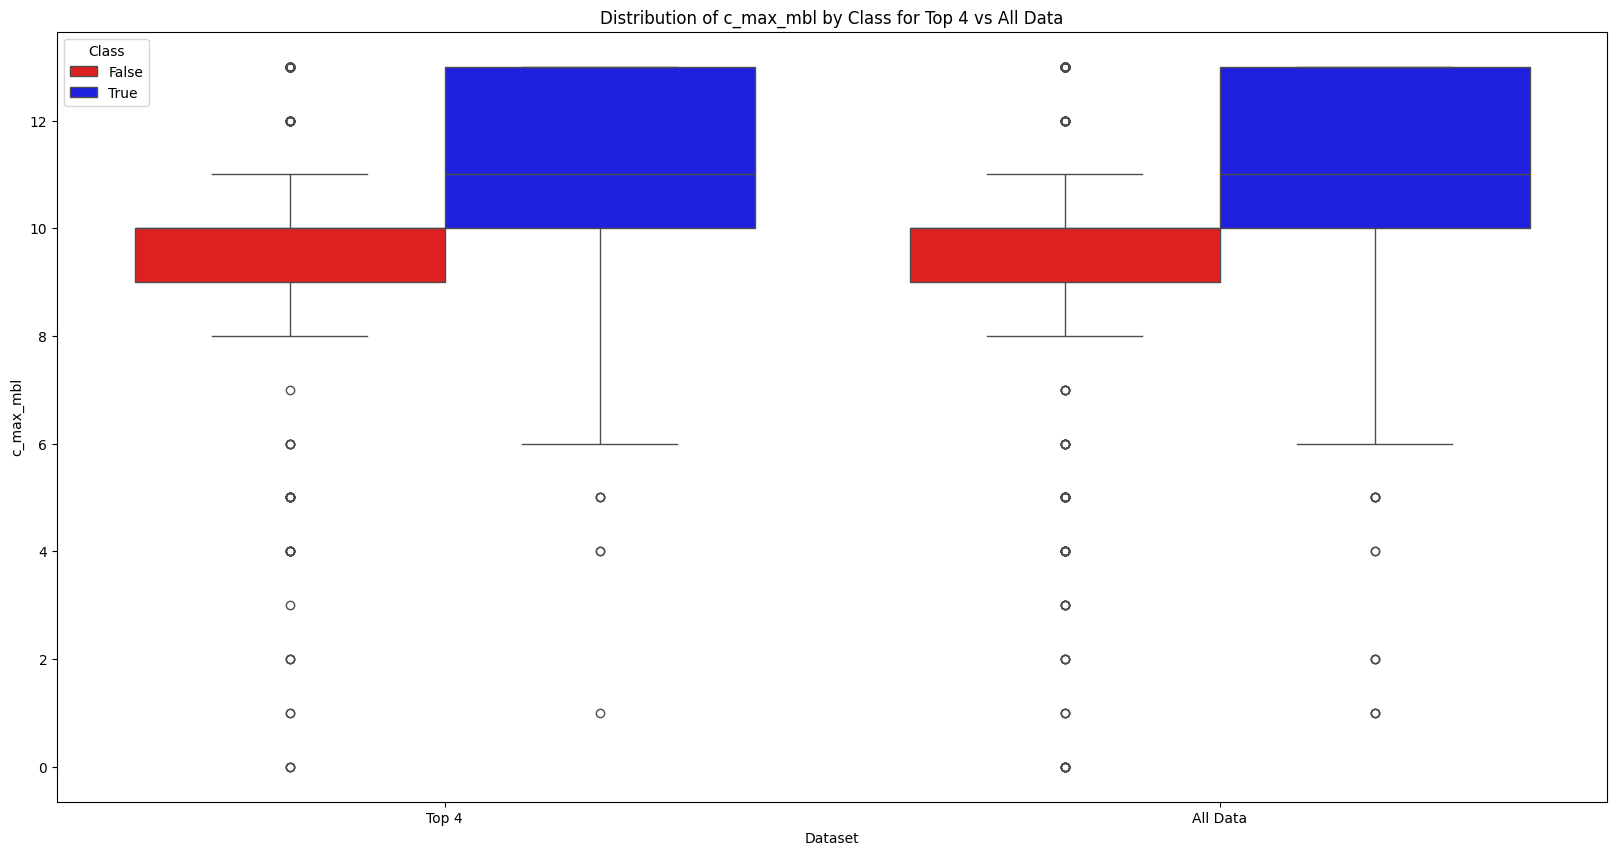

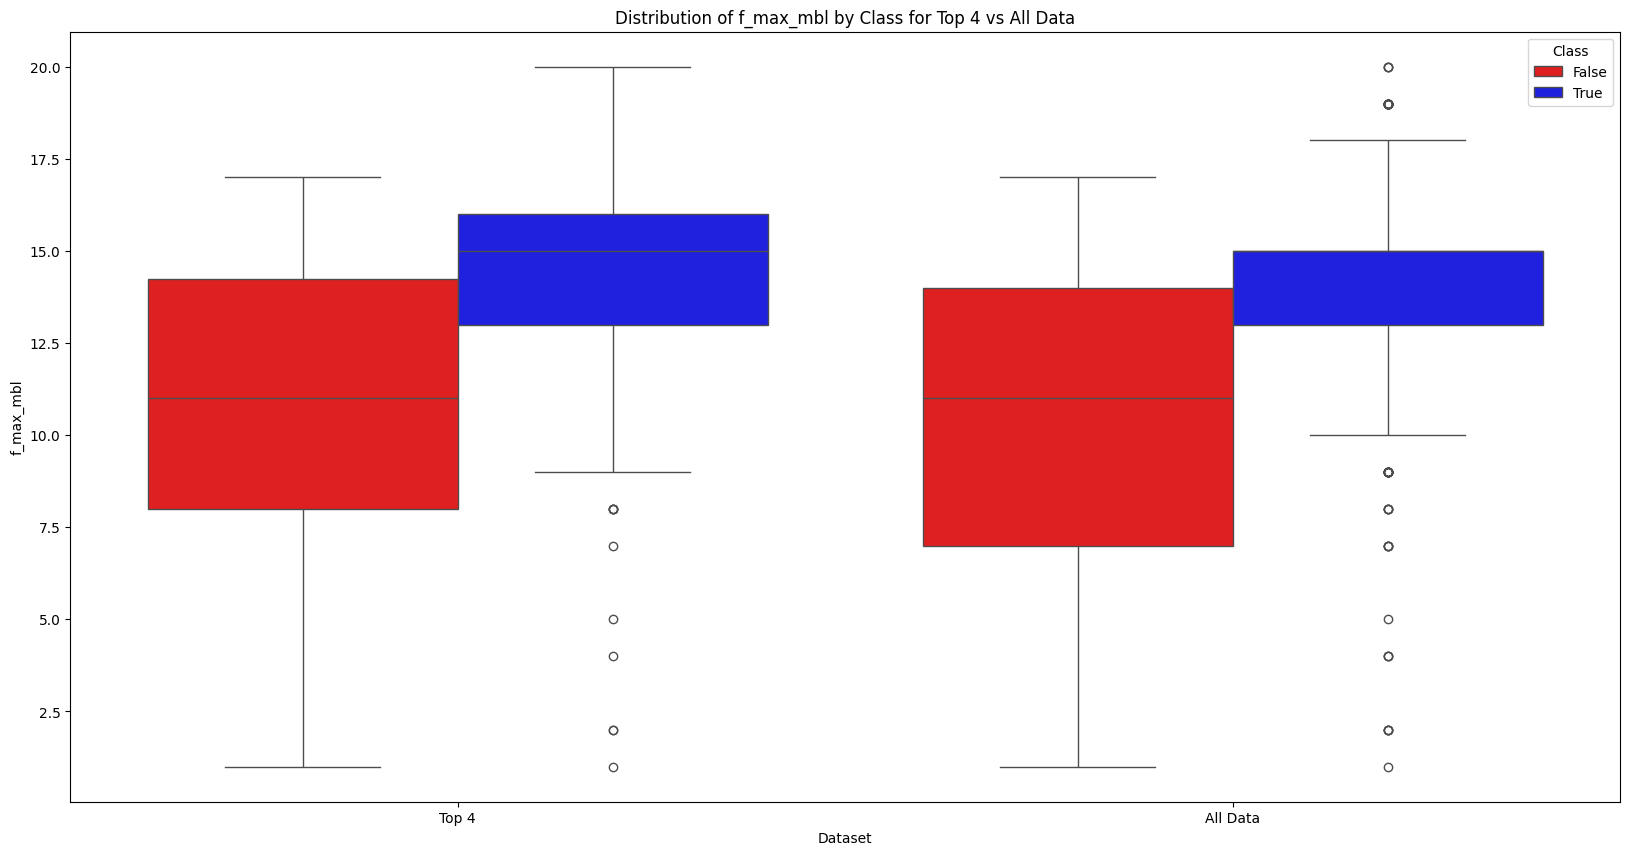

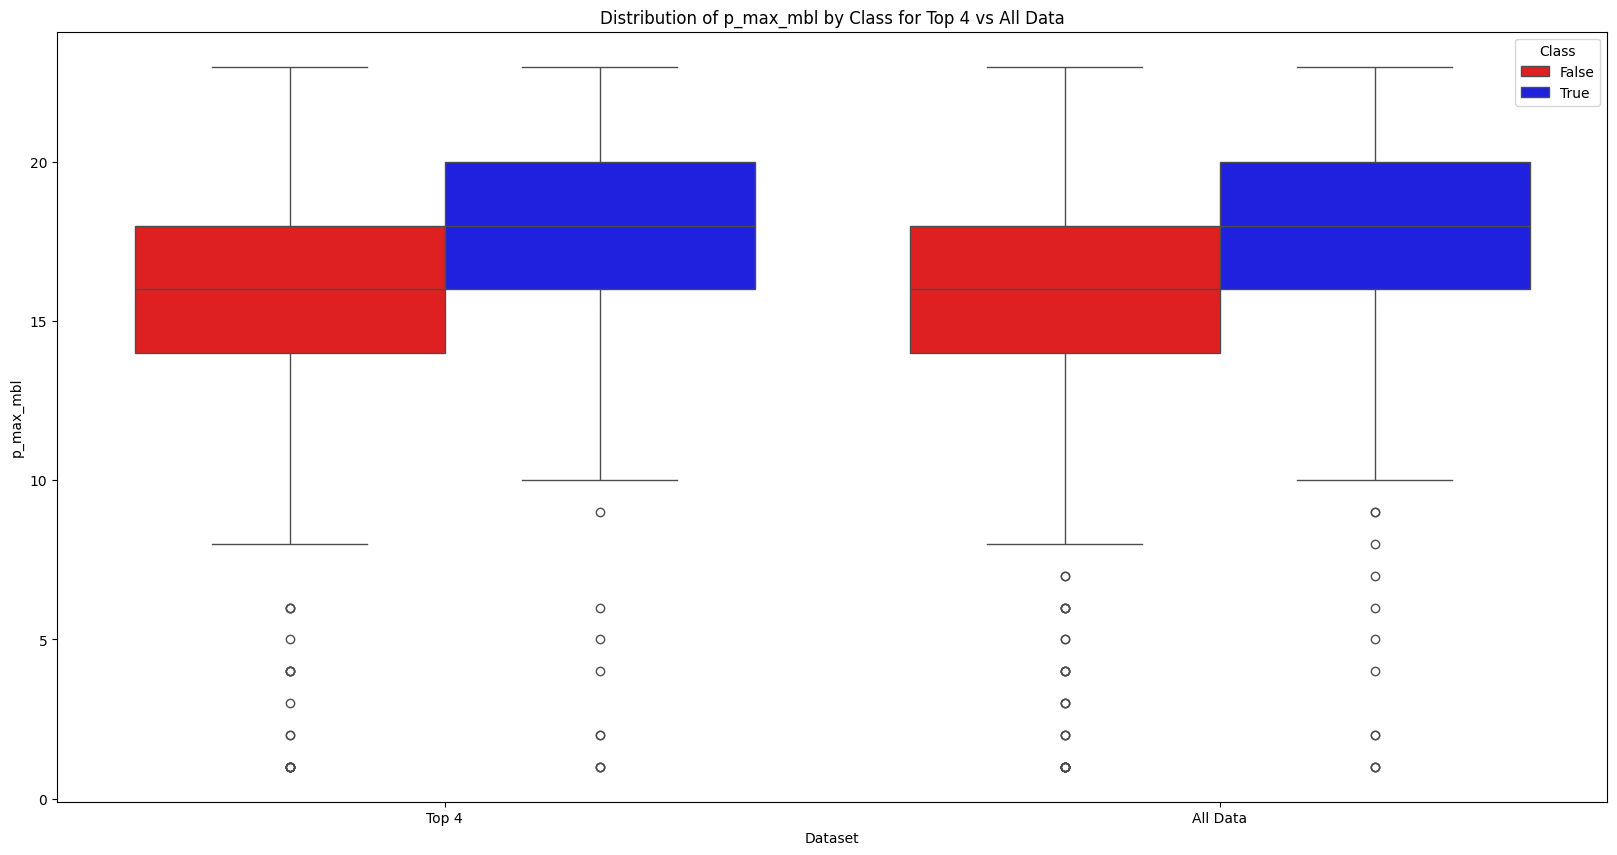

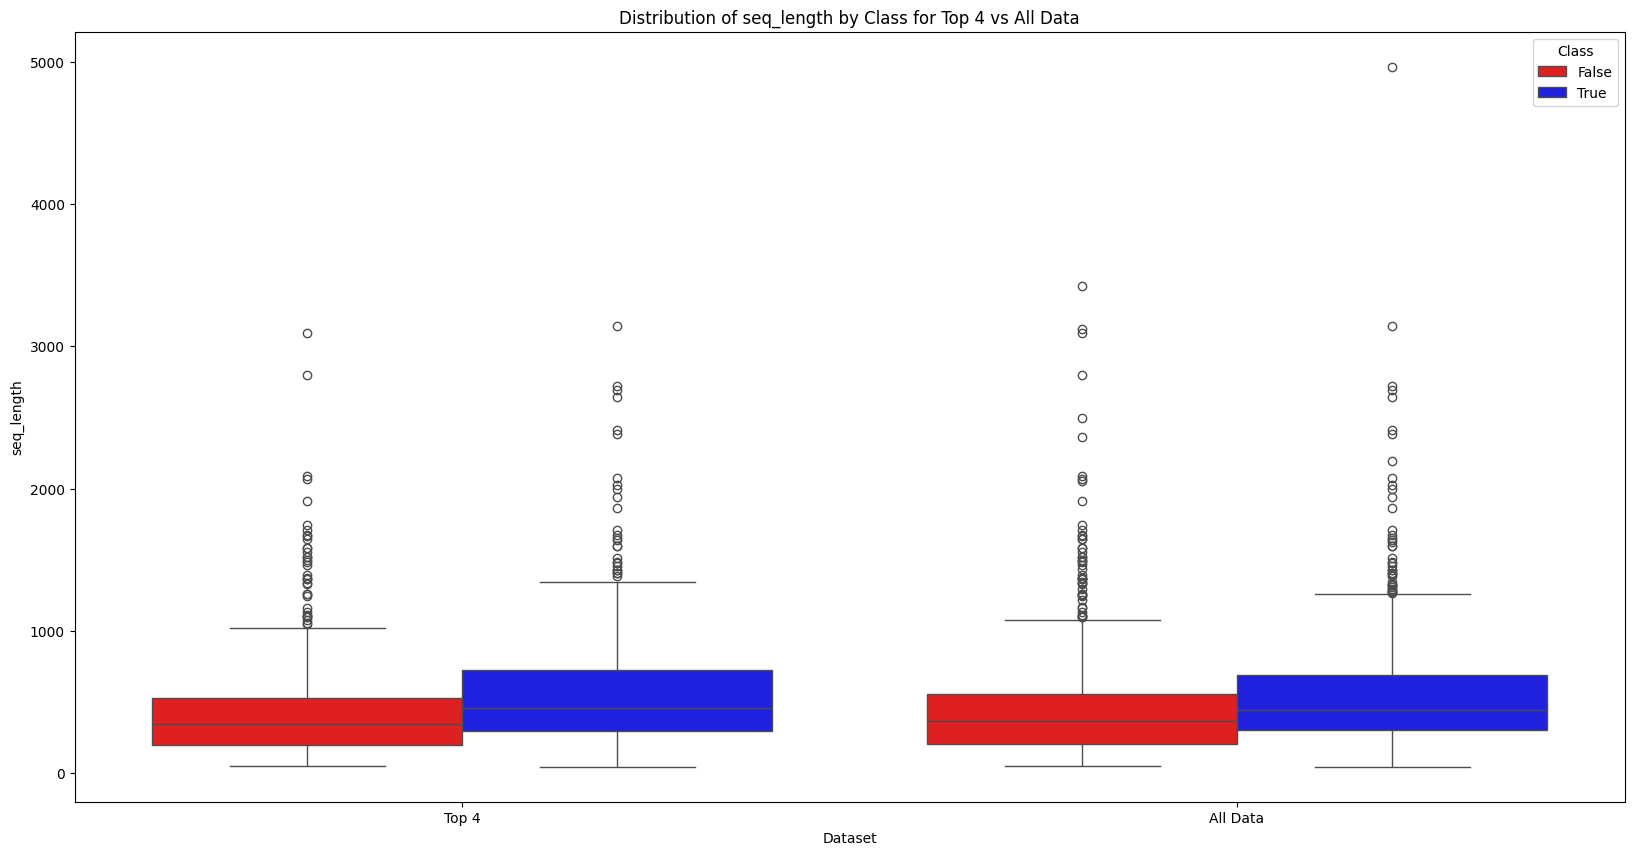

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Add a column to indicate the dataset source
df_top_4_filtered["dataset"] = "Top 4"
merged_df["dataset"] = "All Data"

# Combine the two DataFrames
combined_df = pd.concat([df_top_4_filtered, merged_df], ignore_index=True)

# Plot for each feature
for feature in features:
    plt.figure(figsize=(20, 10))
    sns.boxplot(data=combined_df, x="dataset", y=feature, hue="class", palette={False: "red", True: "blue"})
    plt.title(f"Distribution of {feature} by Class for Top 4 vs All Data")
    plt.xlabel("Dataset")
    plt.ylabel(feature)
    plt.legend(title="Class")
    
    # Save the plot before showing it
    plt.savefig(f"boxplot_{feature}_top4_vs_all_data.png", bbox_inches="tight")
    
    # Show the plot
    plt.show()
    
    # Close the figure
    plt.close()

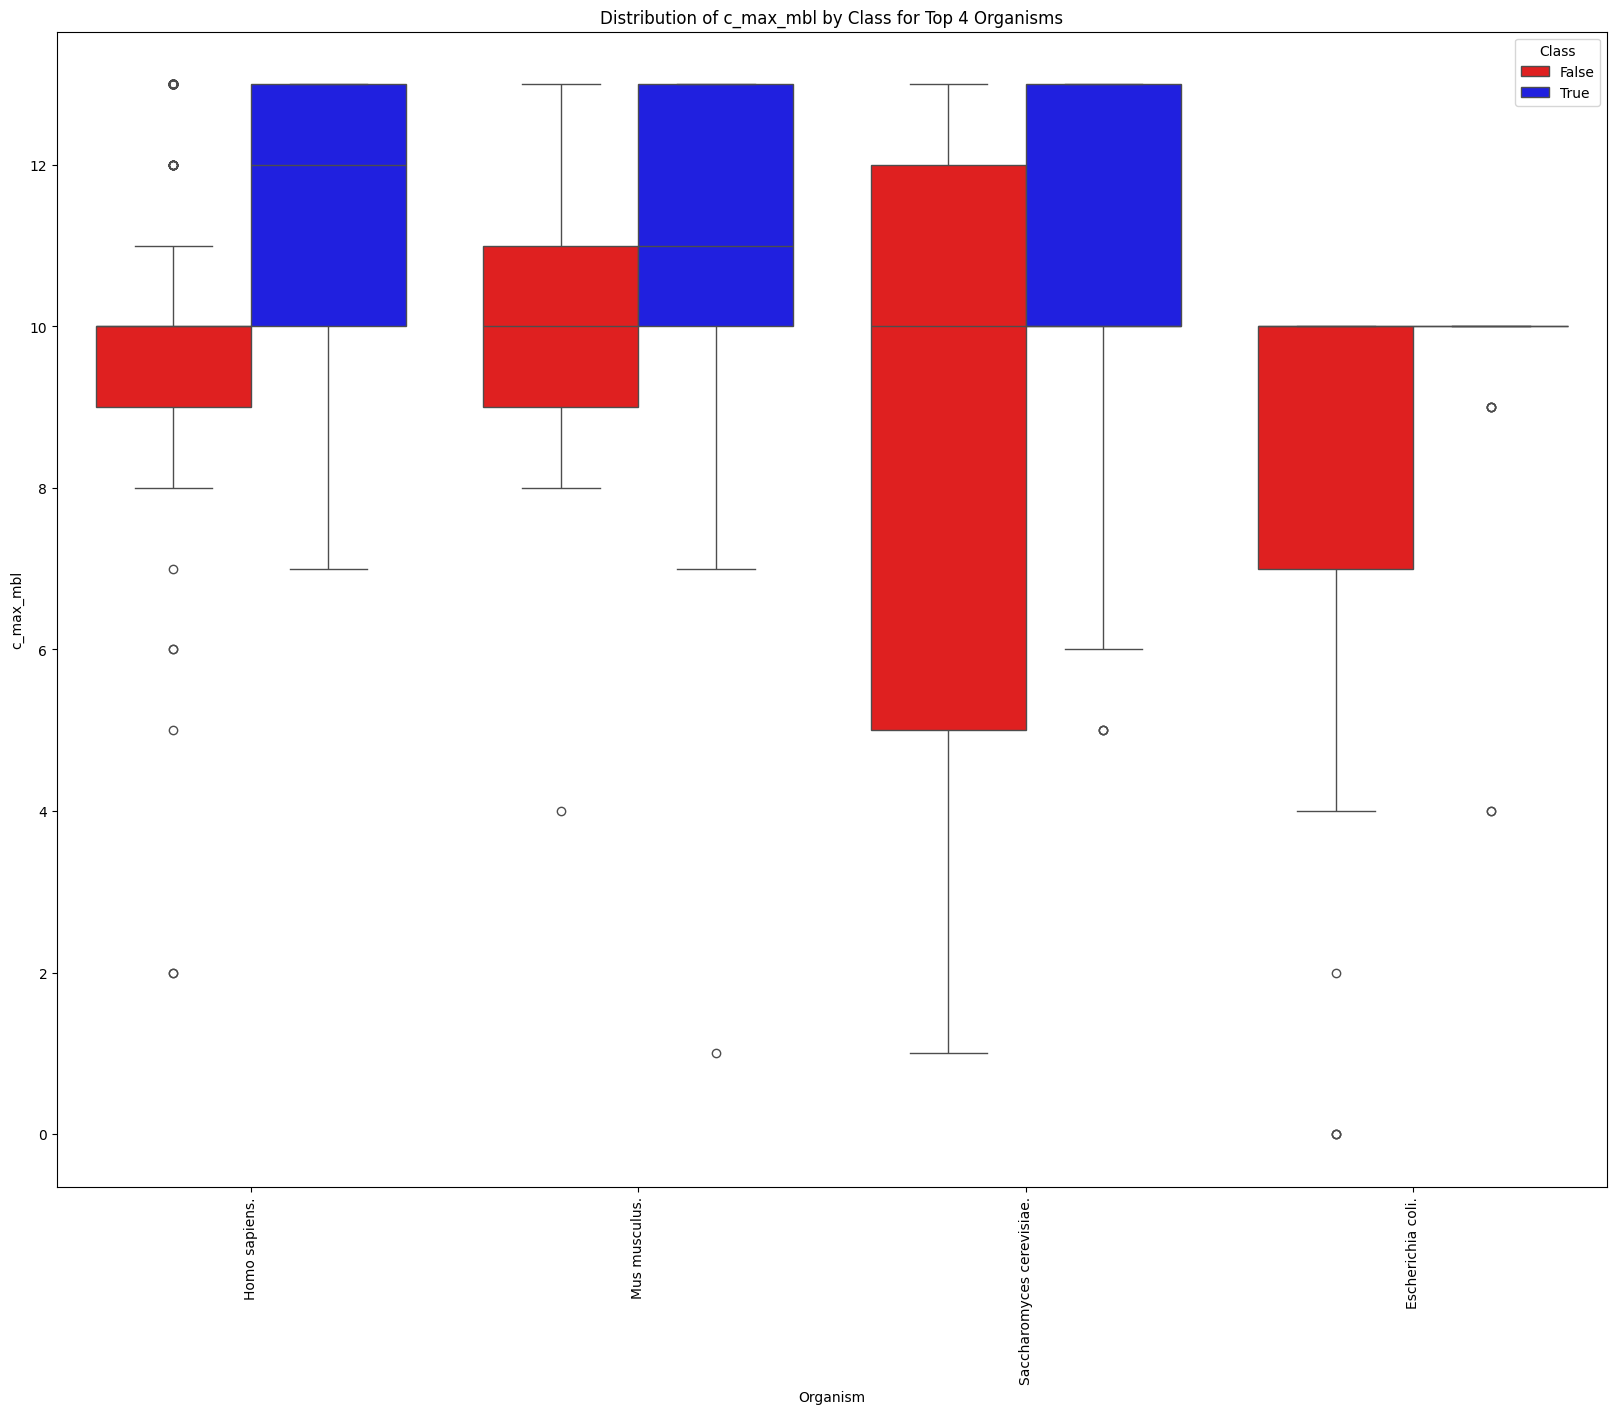

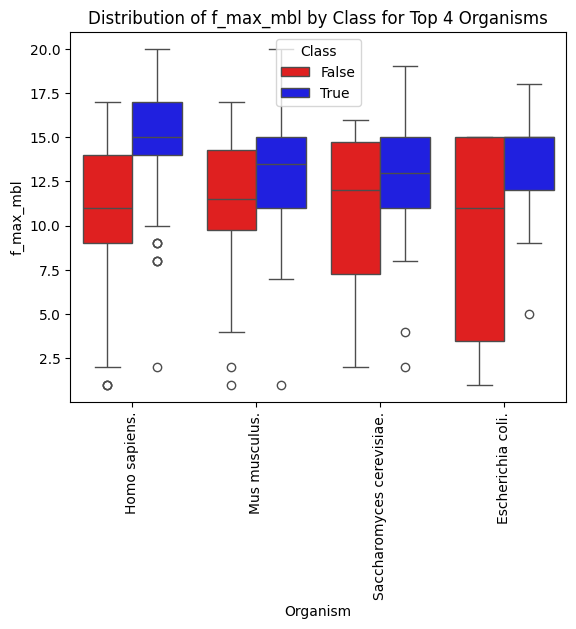

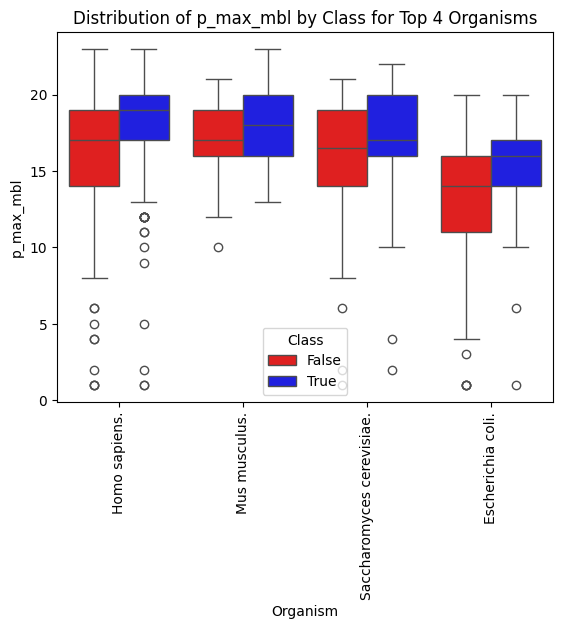

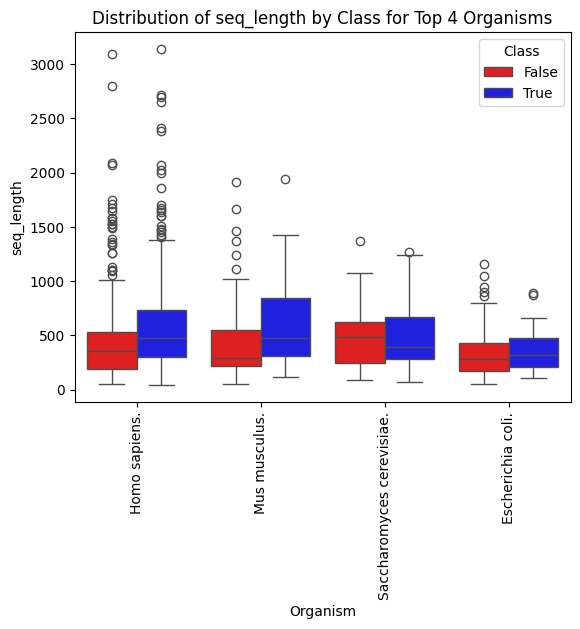

In [18]:
plt.figure(figsize=(20, 15))

for i, feature in enumerate(features, 1):
    sns.boxplot(data=df_top_4_filtered, x="organism", y=feature, hue="class", palette={False: "red", True: "blue"})
    plt.title(f"Distribution of {feature} by Class for Top 4 Organisms")
    plt.xlabel("Organism")
    plt.ylabel(feature)
    plt.xticks(rotation=90)
    plt.legend(title="Class")

    # Save the plot
    plt.savefig(f"boxplot_{feature}_top4_organisms.png")

    # Show the plot
    plt.show()
    
    # Close the figure
    plt.close()

In [145]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import umap
import plotly.express as px


def _reduce_embeddings_3d(method, embeddings, n_components=3):
    """Helper function to reduce embeddings to 3D."""
    if method == "PCA":
        reducer = PCA(n_components=n_components)
    elif method == "UMAP":
        reducer = umap.UMAP(n_components=n_components, random_state=42)
    elif method == "KMeans2":
        reducer = KMeans(n_clusters=2, random_state=42)
        return reducer.fit_predict(embeddings)  # Return cluster labels for KMeans
    else:
        raise ValueError("Unsupported method. Use 'PCA', 'UMAP', or 'KMeans2'.")
    
    return reducer.fit_transform(embeddings)

def _get_colors(labels):
    """Helper function to generate colors for labels."""
    color_map = {
        False: "red",  # Assign red to Class False
        True: "blue"   # Assign blue to Class True
    }
    unique_labels = np.unique(labels)
    colors = {label: color_map.get(label, "gray") for label in unique_labels}  # Default to gray if not specified
    return colors

def _plot_3d(ax, reduced, labels, title):
    """Helper function to plot 3D scatter."""
    colors = _get_colors(labels)
    for label in np.unique(labels):
        mask = labels == label
        ax.scatter(reduced[mask, 0], reduced[mask, 1], reduced[mask, 2], 
                   label=f"Class {label}", color=colors[label], alpha=0.6)
    ax.set_title(title)
    ax.legend()

def _plot_kmeans_3d(ax, embeddings, clusters, title):
    """Helper function to plot KMeans clustering in 3D."""
    ax.scatter(embeddings[:, 0], embeddings[:, 1], embeddings[:, 2], 
               c=clusters, cmap="coolwarm", alpha=0.6)
    ax.set_title(title)

def plots3D(method, dfs_dict, label_col="class", figsize=(15, 5), title=None):
    """
    Plot PCA, UMAP, or KMeans2 for sequence embeddings in 3D.

    Parameters:
        method (str): One of "PCA", "UMAP", "KMeans2".
        dfs_dict (dict): Dictionary of DataFrames {name: DataFrame}.
        label_col (str): Column name for labels (default: "class").
        figsize (tuple): Figure size (default: (15, 5)).
        title (str): Title for the entire plot.
    """
    fig = plt.figure(figsize=figsize)
    fig.suptitle(title, fontsize=16)
    
    for i, (name, df) in enumerate(dfs_dict.items(), start=1):
        embeddings = np.vstack(df["embedding"].to_numpy())
        labels = df[label_col].values if label_col in df.columns else np.zeros(len(df))
        
        ax = fig.add_subplot(1, len(dfs_dict), i, projection="3d")
        
        if method == "KMeans2":
            clusters = _reduce_embeddings_3d(method, embeddings)
            _plot_kmeans_3d(ax, embeddings, clusters, f"{name} ({method})")
        else:
            reduced = _reduce_embeddings_3d(method, embeddings)
            _plot_3d(ax, reduced, labels, f"{name} ({method})")
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

def interactive_3Dplot(method, dfs_dict, label_col="class", id_col="code", title=None):
    """
    Create interactive 3D plots using Plotly.

    Parameters:
        method (str): One of "PCA", "UMAP", "KMeans2".
        dfs_dict (dict): Dictionary of DataFrames {name: DataFrame}.
        label_col (str): Column name for labels (default: "class").
        id_col (str): Column name for unique identifiers (default: "code").
        title (str): Title for the entire plot.
    """
    for name, df in dfs_dict.items():
        embeddings = np.vstack(df["embedding"].to_numpy())
        labels = df[label_col].values if label_col in df.columns else np.zeros(len(df))
        ids = df[id_col].values if id_col in df.columns else np.arange(len(df))
        
        # Reduce embeddings to 3D
        reduced = _reduce_embeddings_3d(method, embeddings)
        
        # Create a DataFrame for Plotly
        plot_df = pd.DataFrame(reduced, columns=["x", "y", "z"])
        plot_df[label_col] = labels
        plot_df[id_col] = ids  # Add the unique identifier column
        
        # Plot with Plotly
        fig = px.scatter_3d(
            plot_df, x="x", y="y", z="z", color=label_col,
            hover_data={id_col: True, "x": False, "y": False, "z": False},  # Show id_col on hover
            title=f"{name} ({method})",
            color_discrete_map={False: "red", True: "blue"}  # Force red/blue for False/True
        )
        fig.show()

In [16]:
def load_embeddings_with_labels(embed_path, label_path, id_col="code"):
    df_embed = pd.read_csv(embed_path)
    df_labels = pd.read_csv(label_path)

    print(f"Loaded {len(df_embed)} embeddings from {embed_path}.")
    print(f"Loaded {len(df_labels)} labels from {label_path}.")

    df = df_embed.merge(df_labels, how="inner", left_on=id_col, right_on="uniprot_id")

    # Fallback to catch either dim_0 or numbered columns like "0", "1", ...
    emb_cols = [col for col in df.columns if col.startswith("dim_") or col.isdigit()]
    if not emb_cols:
        raise ValueError(f"No embedding columns found in {embed_path}. Columns: {df.columns.tolist()}")

    return df

In [33]:
# Paths
PATHS_EMB = {
    "ESM": "../../../DATASETS/embeddings/ESM_sequence_embeddings_with_accession.csv",
    "ProtT5": "../../../DATASETS/embeddings/ProtT5_sequence_embeddings_with_accession.csv",
    "ProstT5": "../../../DATASETS/embeddings/ProstT5_sequence_embeddings_with_accession.csv"
}

# Load all datasets
all_dfs = {name: load_embeddings_with_labels(path, PATH_labels) for name, path in PATHS_EMB.items()}

key_features = ["accession_code", "organism"] + numerical_features

# Create a new dictionary to organize the data
organized_dfs = {
    "Features": df[key_features],  # Add the numerical features from df
    "ESM": all_dfs["ESM"].filter(regex="^dim_\\d+$"),  # Select only embedding columns for ESM
    "ProtT5": all_dfs["ProtT5"].filter(regex="^dim_\\d+$"),  # Select only embedding columns for ProtT5
    "ProstT5": all_dfs["ProstT5"].filter(regex="^dim_\\d+$")  # Select only embedding columns for ProstT5
}

# Verify the structure of the new dictionary
for key, value in organized_dfs.items():
    print(f"{key}: {value.shape}")

Loaded 1416 embeddings from ../../../DATASETS/embeddings/ESM_sequence_embeddings_with_accession.csv.
Loaded 1433 labels from ../../../DATASETS/raw_data/uniprot_ids_labeled.csv.
Loaded 1416 embeddings from ../../../DATASETS/embeddings/ProtT5_sequence_embeddings_with_accession.csv.
Loaded 1433 labels from ../../../DATASETS/raw_data/uniprot_ids_labeled.csv.
Loaded 1416 embeddings from ../../../DATASETS/embeddings/ProstT5_sequence_embeddings_with_accession.csv.
Loaded 1433 labels from ../../../DATASETS/raw_data/uniprot_ids_labeled.csv.
Features: (1412, 7)
ESM: (1412, 320)
ProtT5: (1412, 1024)
ProstT5: (1412, 1024)


In [ ]:
# Create a dictionary of DataFrames for each organism
all_dfs_by_organisms = {}
for name, df_emb in all_dfs.items():
    for organism in top_4_organisms:
        filtered_df = df_emb[df_emb["organism"] == organism]
        if organism not in all_dfs_by_organisms:
            all_dfs_by_organisms[organism] = {}
        all_dfs_by_organisms[organism][name] = filtered_df

Plotting for organism: Homo sapiens.


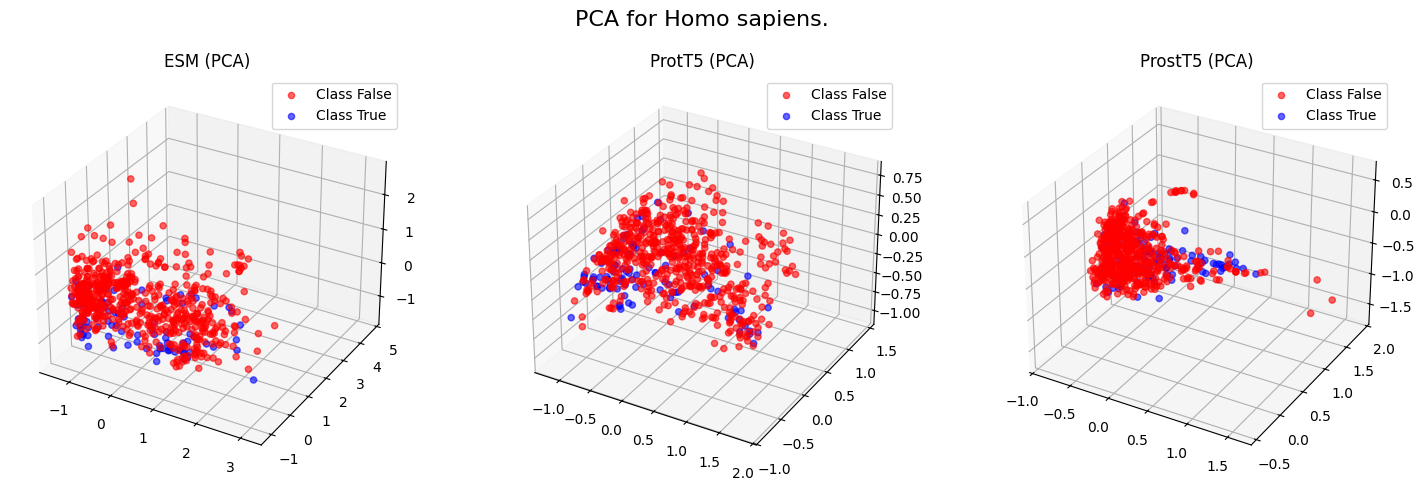

Plotting for organism: Mus musculus.


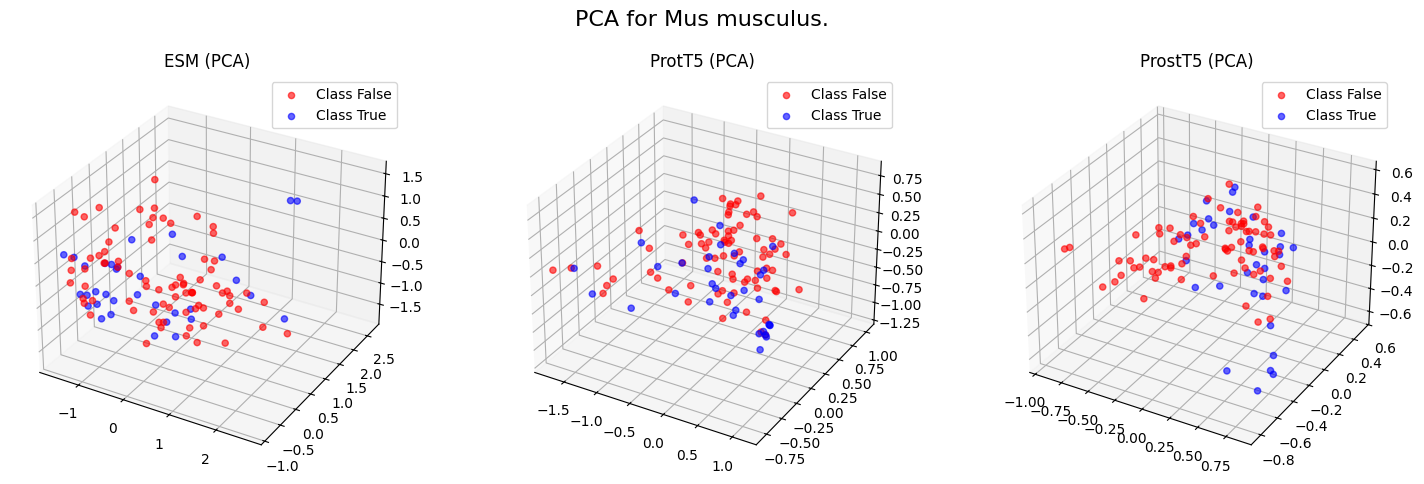

Plotting for organism: Escherichia coli.


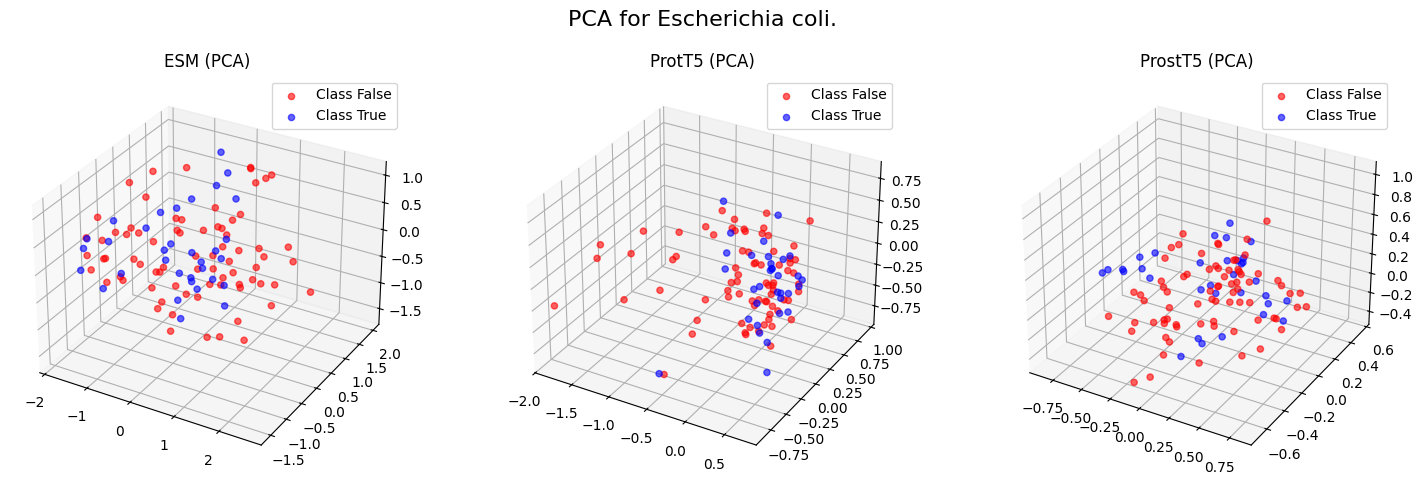

Plotting for organism: Saccharomyces cerevisiae.


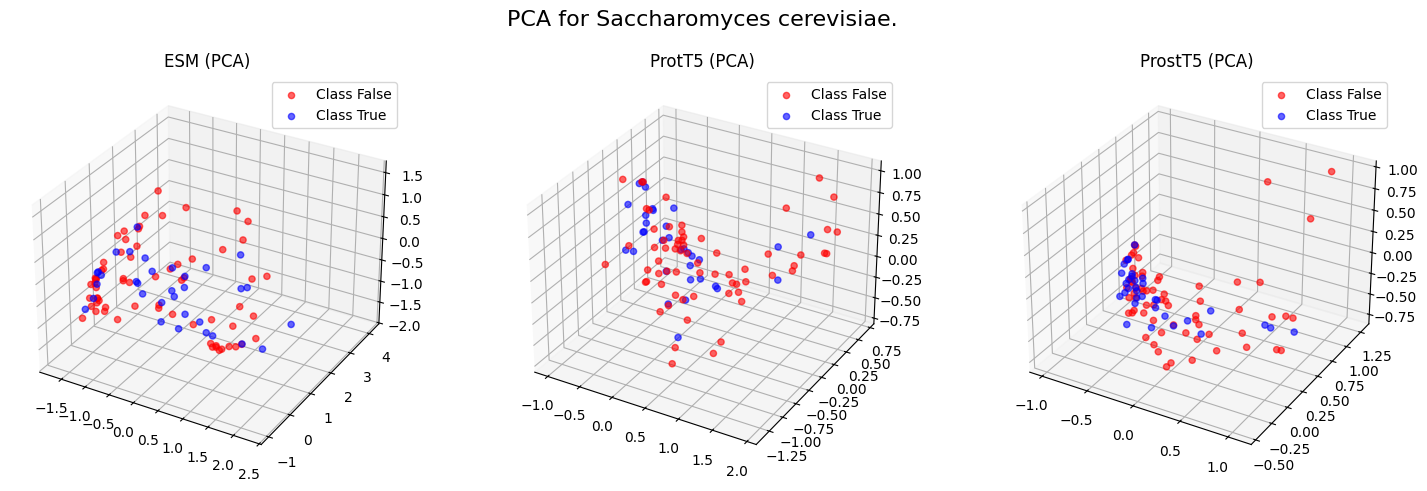

In [22]:
# Run the plots3D function for PCA for each organism
for organism, dfs_dict in all_dfs_by_organisms.items():
    print(f"Plotting for organism: {organism}")
    plots3D("PCA", dfs_dict, label_col="class", title=f"PCA for {organism}")

Plotting for organism: Homo sapiens.


/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.

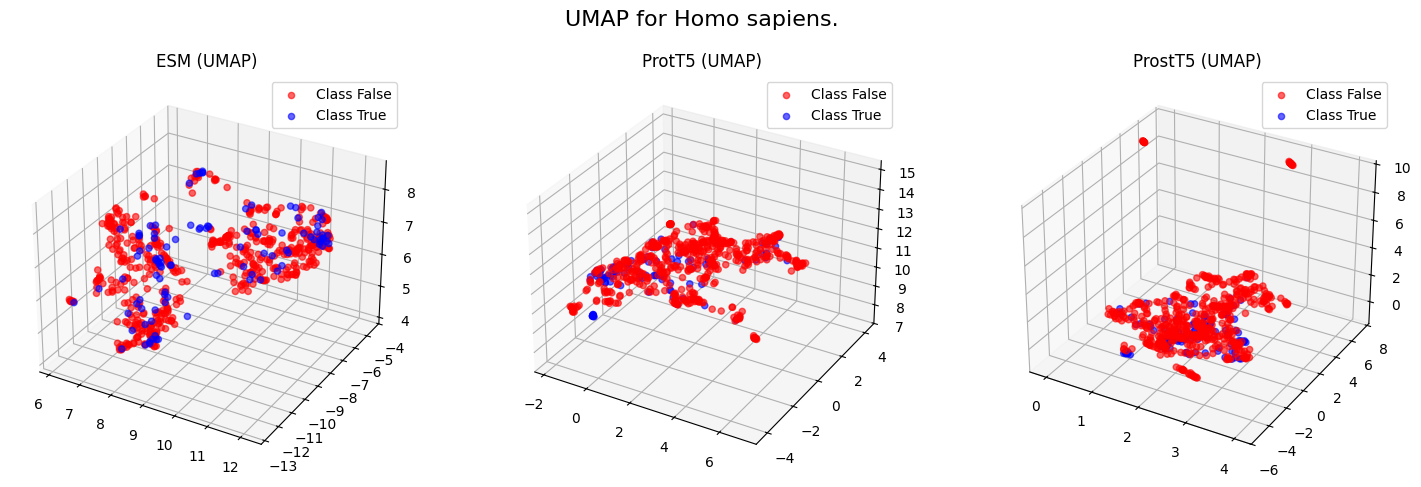

Plotting for organism: Mus musculus.


/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed

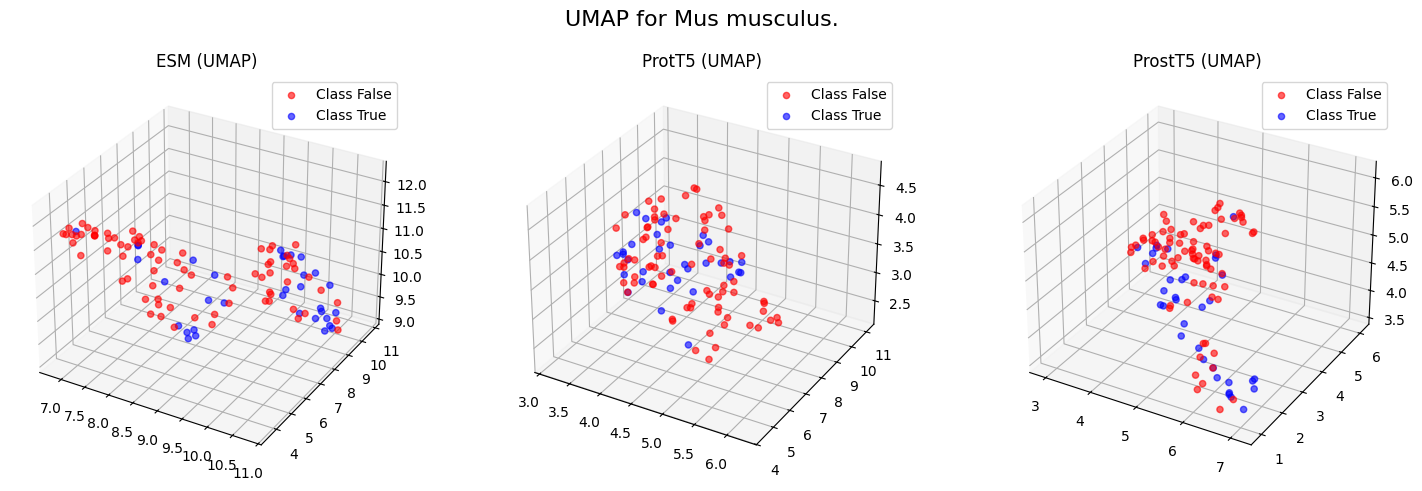

Plotting for organism: Escherichia coli.


/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed

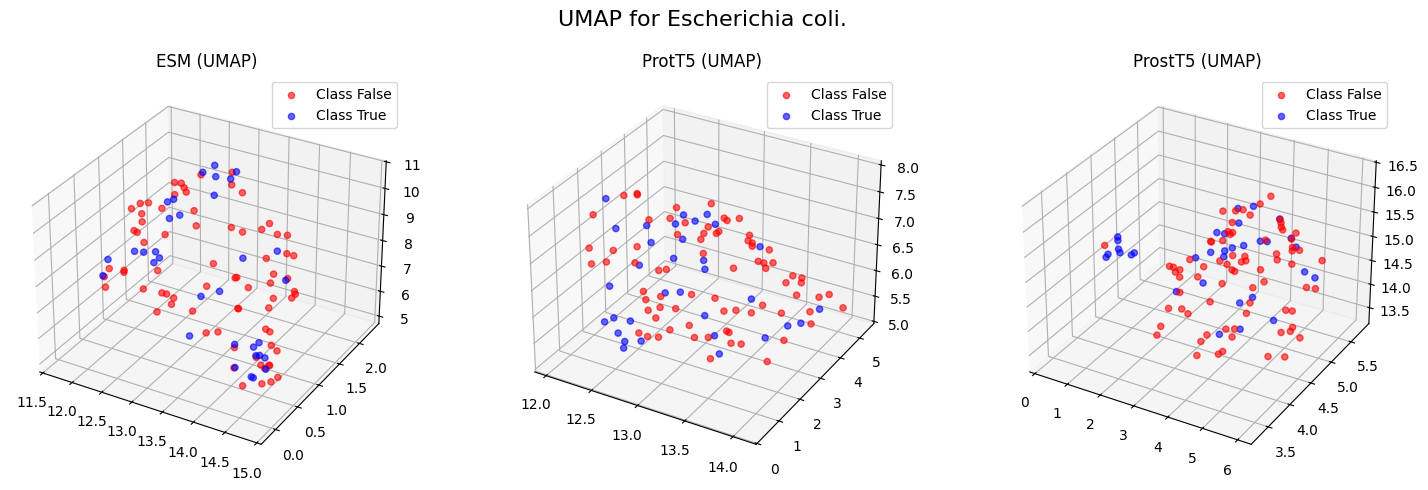

Plotting for organism: Saccharomyces cerevisiae.


/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed

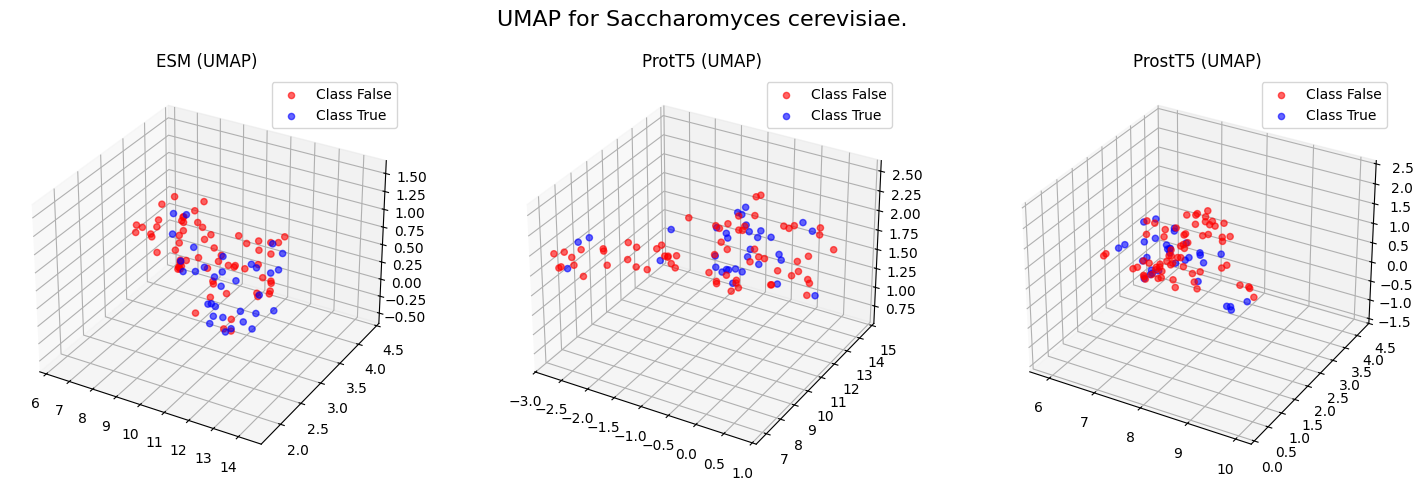

In [23]:
# Run the plots3D function for PCA for each organism
for organism, dfs_dict in all_dfs_by_organisms.items():
    print(f"Plotting for organism: {organism}")
    plots3D("UMAP", dfs_dict, label_col="class", title=f"UMAP for {organism}")

Plotting for organism: Homo sapiens.


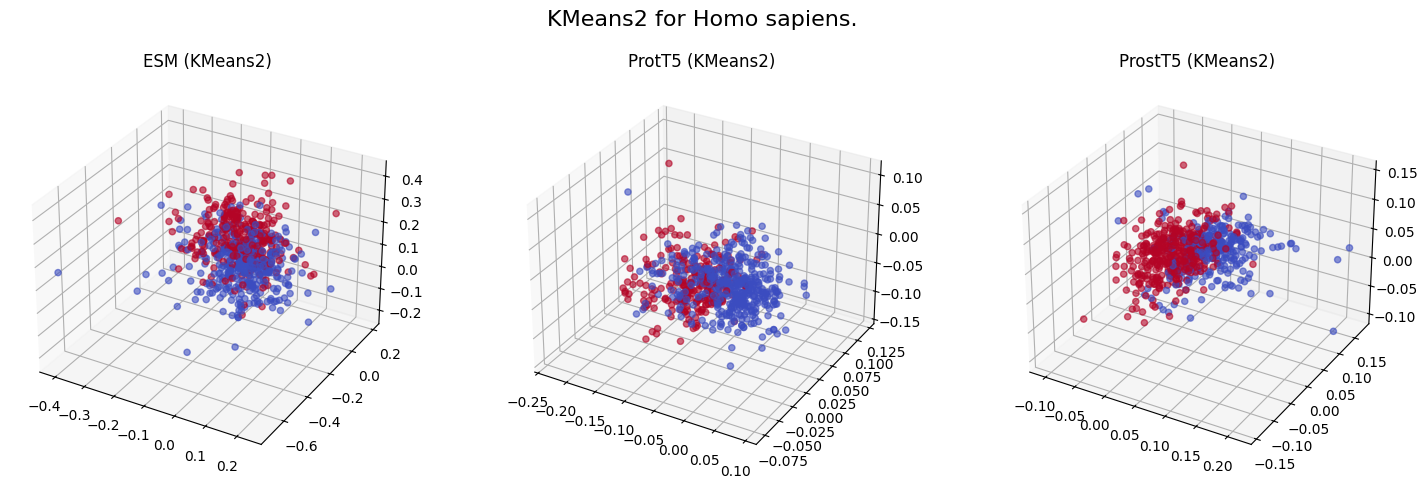

Plotting for organism: Mus musculus.


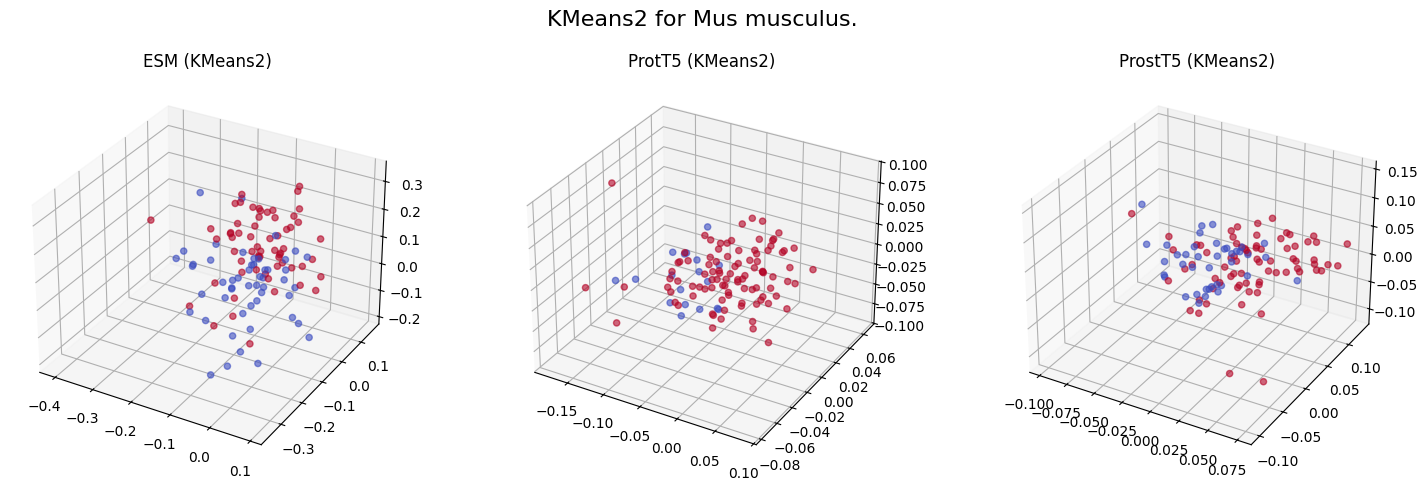

Plotting for organism: Escherichia coli.


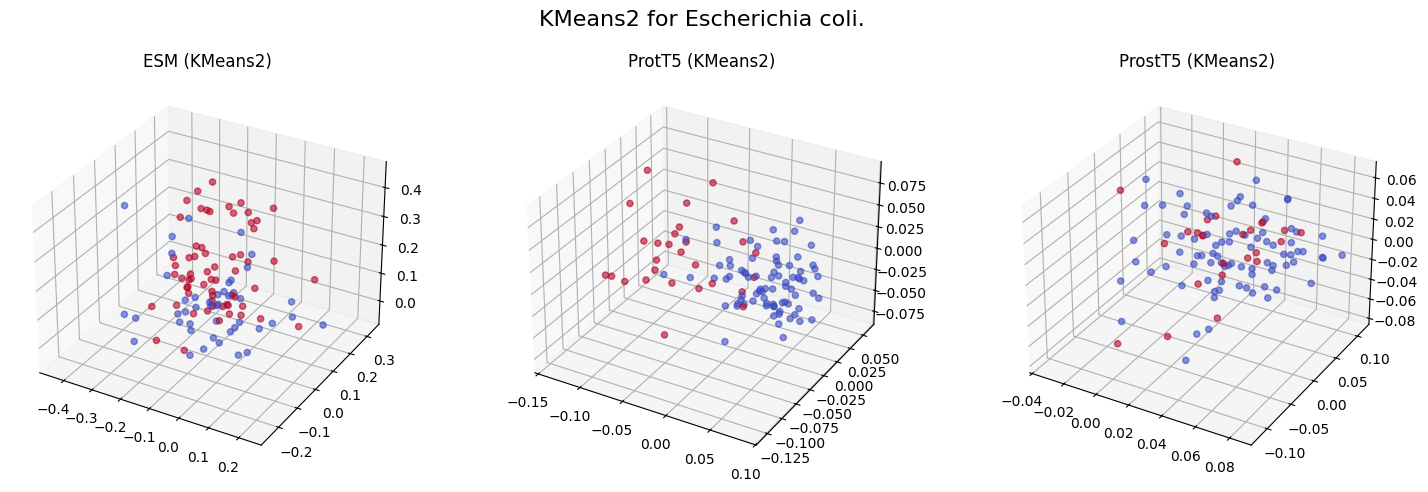

Plotting for organism: Saccharomyces cerevisiae.


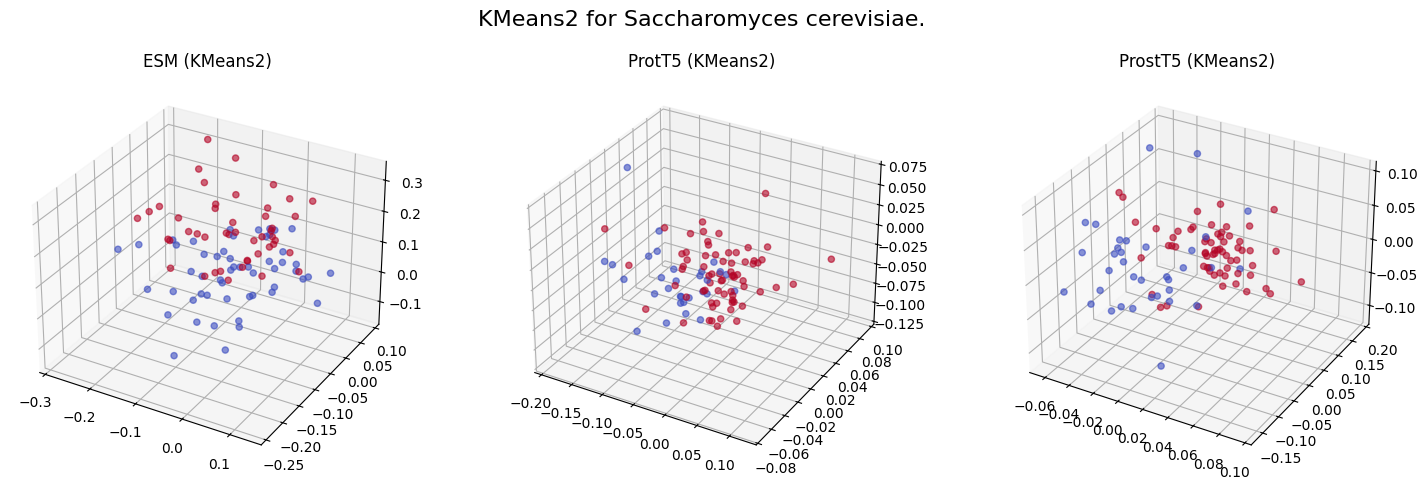

In [24]:
# Run the plots3D function for PCA for each organism
for organism, dfs_dict in all_dfs_by_organisms.items():
    print(f"Plotting for organism: {organism}")
    plots3D("KMeans2", dfs_dict, label_col="class", title=f"KMeans2 for {organism}")

In [19]:
PATH_SAVE_IMG = "../../../IMGS/df_analysis/PCA_UMAP_KMeans2/"

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import umap
from matplotlib import colormaps  # Updated for Matplotlib 3.7+
from matplotlib.lines import Line2D  # For custom legend

def _reduce_embeddings_3d(method, embeddings, n_components=3):
    """Helper function to reduce embeddings to 3D."""
    if method == "PCA":
        reducer = PCA(n_components=n_components)
    elif method == "UMAP":
        reducer = umap.UMAP(n_components=n_components, random_state=42)
    elif method == "KMeans2":
        reducer = KMeans(n_clusters=2, random_state=42)
        return reducer.fit_predict(embeddings)  # Return cluster labels for KMeans
    else:
        raise ValueError("Unsupported method. Use 'PCA', 'UMAP', or 'KMeans2'.")
    
    return reducer.fit_transform(embeddings)

def _get_fade_colors(values, labels, colormap_true="Blues", colormap_false="Reds"):
    """
    Generate colors with a fade effect based on the MBL values and class labels.

    Parameters:
        values (array-like): Array of MBL values to map to colors.
        labels (array-like): Array of class labels (True/False).
        colormap_true (str): Colormap for True class.
        colormap_false (str): Colormap for False class.

    Returns:
        colors (array): Array of RGBA colors.
    """
    norm = plt.Normalize(vmin=np.min(values), vmax=np.max(values))  # Normalize MBL values
    cmap_true = colormaps.get_cmap(colormap_true)  # Updated for Matplotlib 3.7+
    cmap_false = colormaps.get_cmap(colormap_false)  # Updated for Matplotlib 3.7+

    colors = [
        cmap_true(norm(value)) if label else cmap_false(norm(value))
        for value, label in zip(values, labels)
    ]
    return np.array(colors)  # Return as a NumPy array for compatibility with Matplotlib

def _plot_3d_with_fade(ax, reduced, mbl_values, labels, title, colormap_true="Blues", colormap_false="Reds"):
    """Helper function to plot 3D scatter with fade effect based on MBL values."""
    colors = _get_fade_colors(mbl_values, labels, colormap_true, colormap_false)
    scatter = ax.scatter(reduced[:, 0], reduced[:, 1], reduced[:, 2], c=colors, alpha=0.8)
    ax.set_title(title)

    # Add legend for color intensity
    legend_elements = [
        Line2D([0], [0], color=colormaps.get_cmap(colormap_true)(0.5), lw=4, label="True (MBL Intensity)"),
        Line2D([0], [0], color=colormaps.get_cmap(colormap_false)(0.5), lw=4, label="False (MBL Intensity)")
    ]
    ax.legend(handles=legend_elements, loc="upper right")

def plots3D_with_fade_from_organized(
    method, organized_dfs, mbl_col="c_max_mbl", label_col="class", 
    feature_cols=None, fade_colors=True, figsize=(15, 5), title=None, 
    organism_filter=None, save_img=True
):
    """
    Plot PCA, UMAP, or KMeans2 for sequence embeddings in 3D with optional fade effect 
    and the ability to concatenate additional features with embeddings. Can filter by organism.

    Parameters:
        method (str): One of "PCA", "UMAP", "KMeans2".
        organized_dfs (dict): Dictionary with keys ["Features", "ESM", "ProtT5", "ProstT5"].
        mbl_col (str): Column name for MBL values (default: "c_max_mbl").
        label_col (str): Column name for class labels (default: "class").
        feature_cols (list): List of feature column names to concatenate with embeddings (default: None).
        fade_colors (bool): Whether to apply fade effect based on MBL values (default: True).
        figsize (tuple): Figure size (default: (15, 5)).
        title (str): Title for the entire plot.
        organism_filter (str): Filter to include only data for a specific organism (default: None).
        save_img (bool): Whether to save the plot as an image (default: True).
    """
    # Filter by organism if specified
    features = organized_dfs["Features"]
    if organism_filter:
        features = features[features["organism"] == organism_filter]
        if features.empty:
            print(f"No data found for organism: {organism_filter}")
            return

    # Align indices of features and embeddings
    aligned_indices = features.index
    labels = features[label_col].loc[aligned_indices].values  # Get class labels

    # Concatenate additional features if specified
    additional_features = None
    if feature_cols:
        additional_features = features.loc[aligned_indices, feature_cols].to_numpy()

    fig = plt.figure(figsize=figsize)
    fig.suptitle(title, fontsize=16)

    for i, (name, embeddings_df) in enumerate(organized_dfs.items()):
        if name == "Features":
            continue  # Skip the features key

        # Align embeddings with the filtered features
        aligned_embeddings = embeddings_df.loc[aligned_indices.intersection(embeddings_df.index)].to_numpy()

        # Ensure embeddings and labels are aligned
        aligned_indices_final = aligned_indices.intersection(embeddings_df.index)
        labels_final = features.loc[aligned_indices_final, label_col].values

        # Concatenate embeddings with additional features if specified
        if additional_features is not None:
            aligned_embeddings = np.hstack((aligned_embeddings, additional_features))

        ax = fig.add_subplot(1, len(organized_dfs) - 1, i, projection="3d")  # Exclude features from subplot count

        if method == "KMeans2":
            clusters = _reduce_embeddings_3d(method, aligned_embeddings)
            _plot_kmeans_3d(ax, aligned_embeddings, clusters, f"{name} ({method})")
        else:
            reduced = _reduce_embeddings_3d(method, aligned_embeddings)
            if fade_colors:
                mbl_values = features.loc[aligned_indices_final, mbl_col].values  # Get MBL values
                _plot_3d_with_fade(ax, reduced, mbl_values, labels_final, f"{name} ({method})")
            else:
                _plot_3d(ax, reduced, labels_final, f"{name} ({method})")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # Save the figure
    if save_img:
        if title:
            fig.savefig(PATH_SAVE_IMG + f"{title.replace(' ', '_')}.png", dpi=300, bbox_inches="tight")
        else:
            fig.savefig(PATH_SAVE_IMG + "3D_plot.png", dpi=300, bbox_inches="tight")

In [66]:
mergable_features = ["p_max_mbl", "seq_length"]

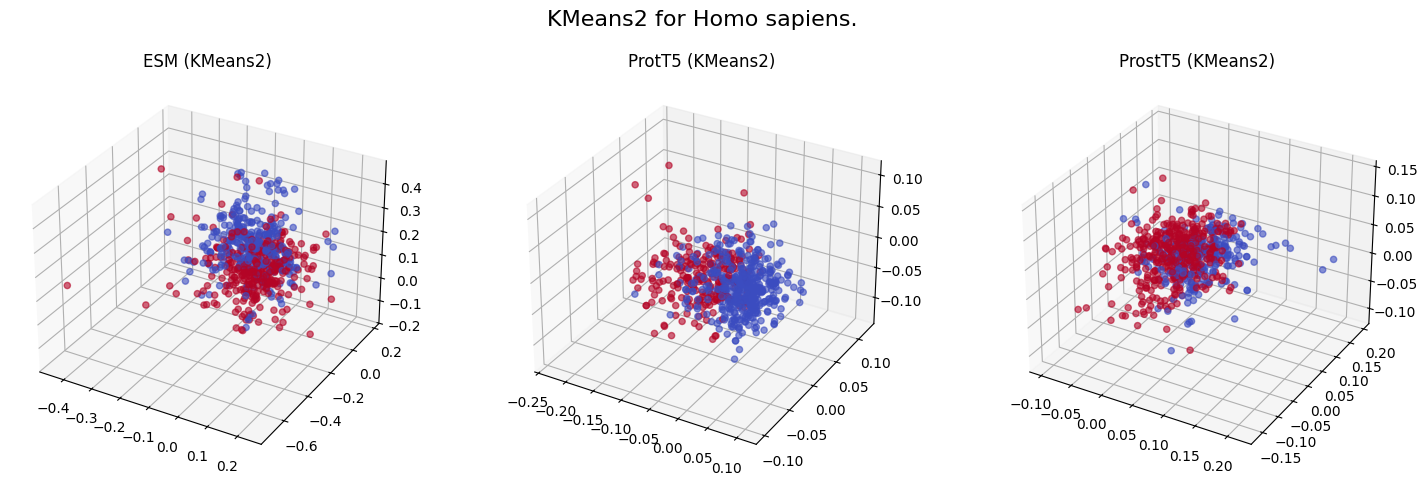

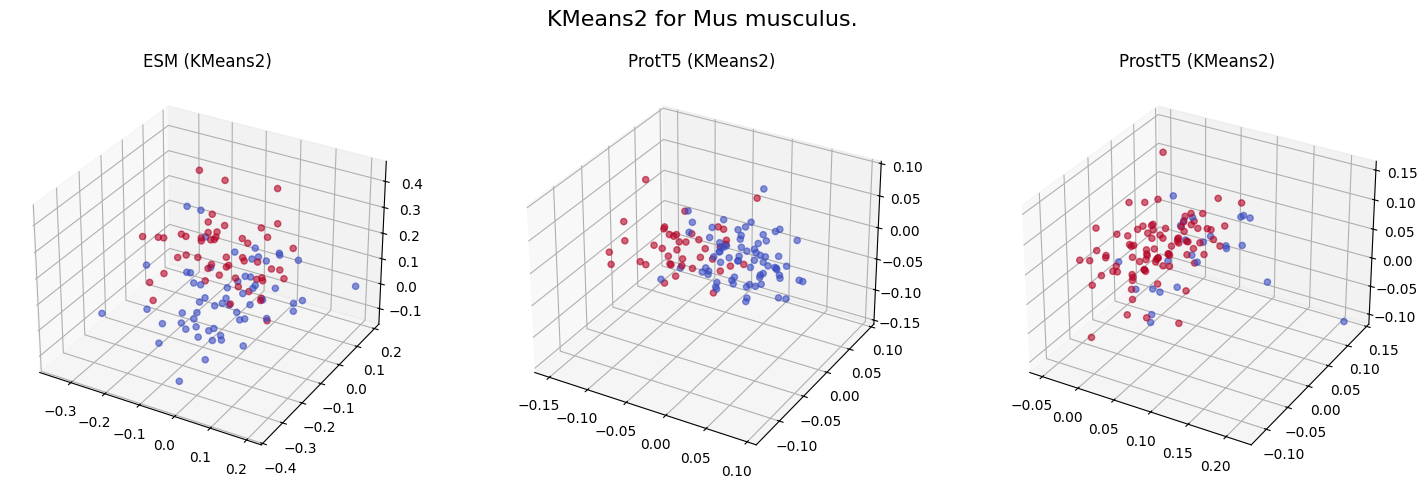

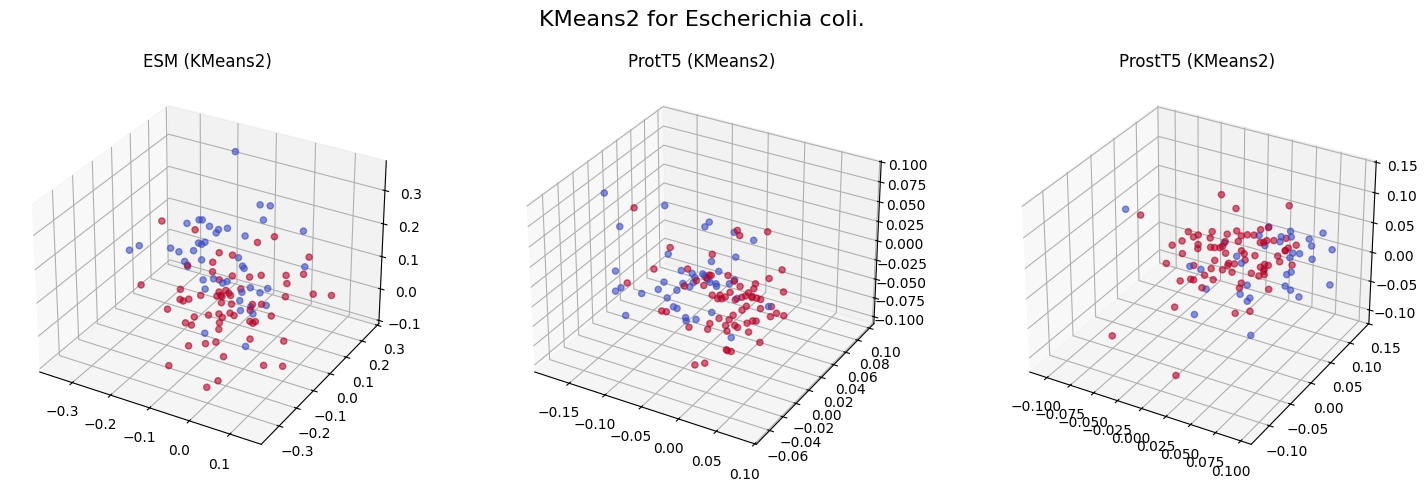

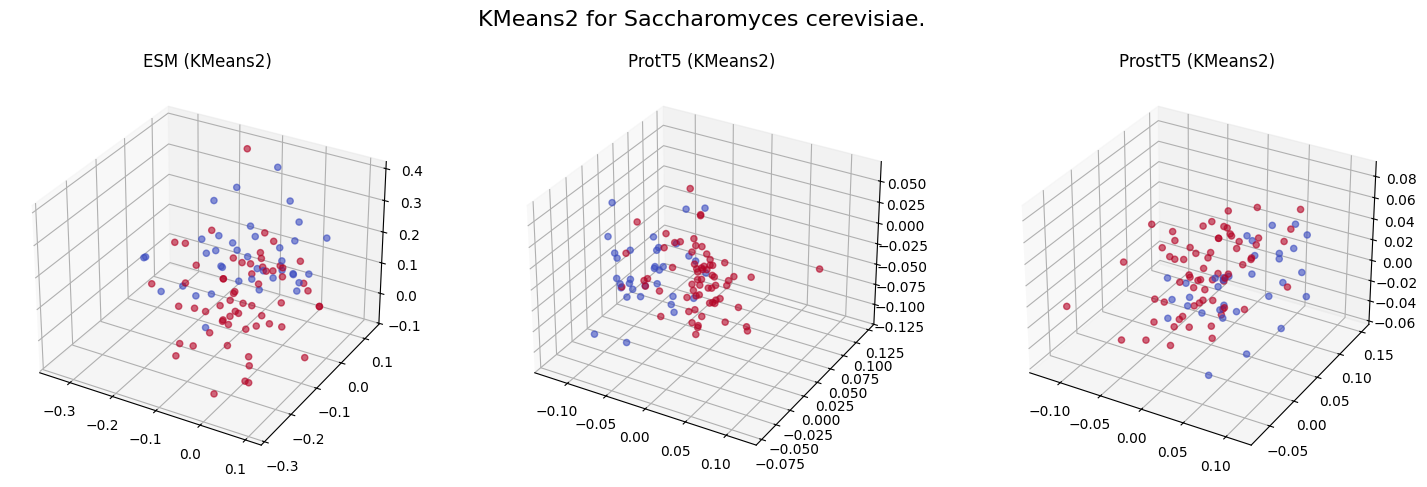

In [81]:

for organism in top_4_organisms:
    plots3D_with_fade_from_organized(
        method="KMeans2",
        organized_dfs=organized_dfs,
        fade_colors=False,  # Disable fade effect
        organism_filter=organism,  # Filter for a specific organism
        title=f"KMeans2 for {organism}",
    )

In [ ]:
filtered_organized_dfs.shape

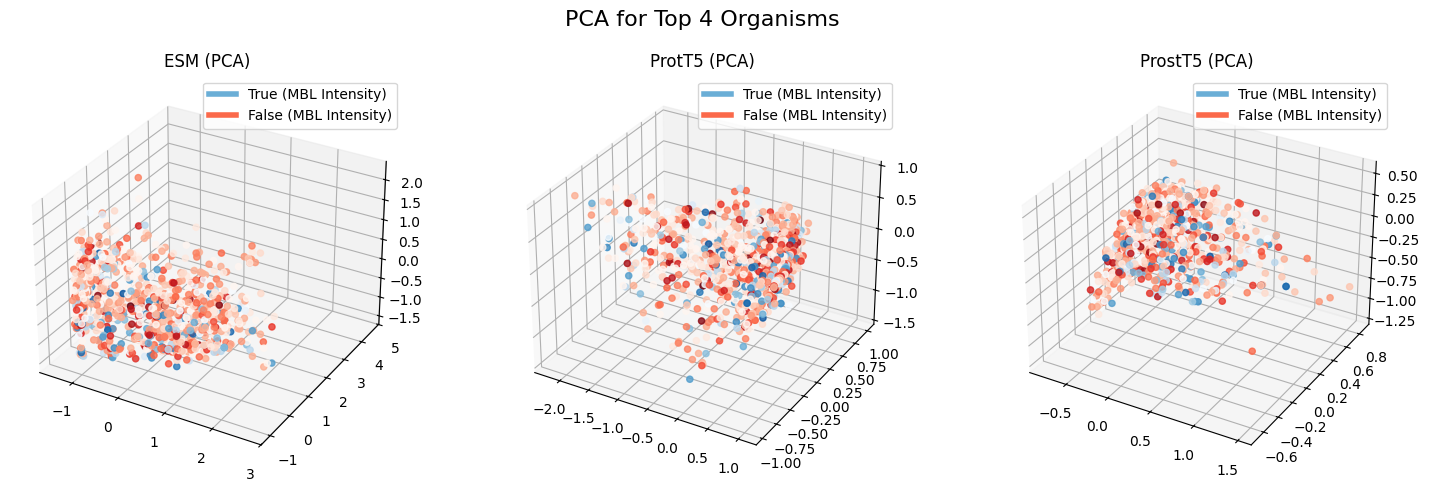

In [38]:
# Define the top 4 organisms
top_4_organisms_list = [
    "Homo sapiens.",
    "Mus musculus.",
    "Escherichia coli.",
    "Saccharomyces cerevisiae."
]

# Filter the Features DataFrame for the top 4 organisms
filtered_features = organized_dfs["Features"][organized_dfs["Features"]["organism"].isin(top_4_organisms_list)]

# Align the indices of the embeddings with the filtered Features
filtered_indices = filtered_features.index.intersection(organized_dfs["ESM"].index)

# Filter embeddings based on the aligned indices
filtered_organized_dfs = {
    "Features": filtered_features.loc[filtered_indices],
    "ESM": organized_dfs["ESM"].loc[filtered_indices],
    "ProtT5": organized_dfs["ProtT5"].loc[filtered_indices],
    "ProstT5": organized_dfs["ProstT5"].loc[filtered_indices],
}

# Plot using the filtered data
plots3D_with_fade_from_organized(
    method="PCA",  # or "UMAP" or "KMeans2"
    organized_dfs=filtered_organized_dfs,
    mbl_col="c_max_mbl",  # Adjust if needed
    label_col="class",
    title="PCA for Top 4 Organisms"
)

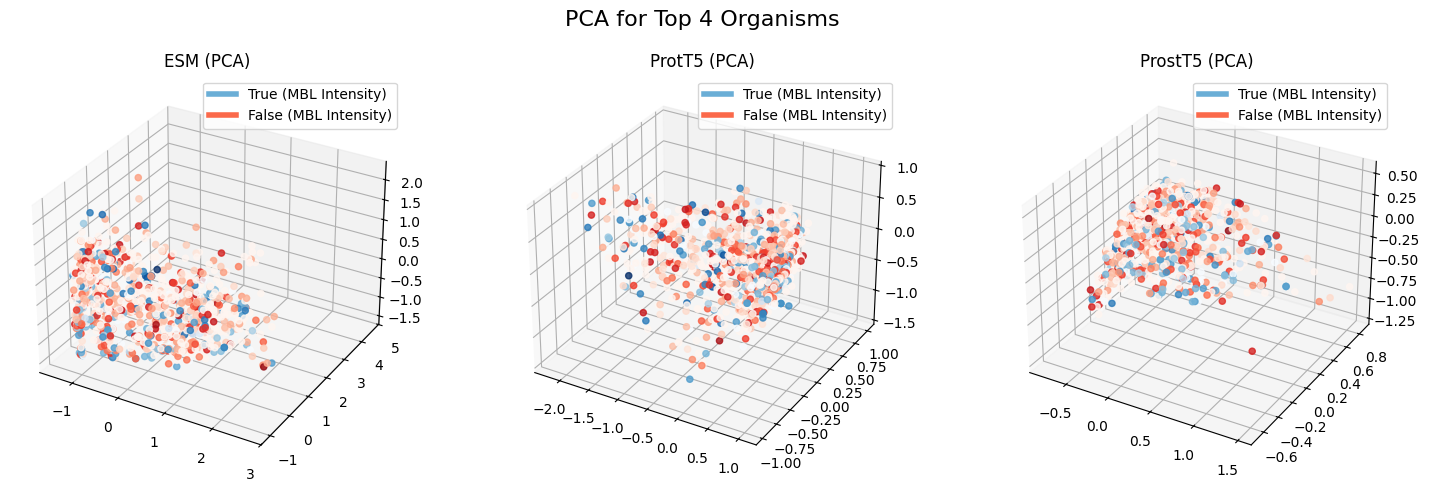

In [47]:
# Plot using the filtered data
plots3D_with_fade_from_organized(
    method="PCA",  # or "UMAP" or "KMeans2"
    organized_dfs=filtered_organized_dfs,
    mbl_col="f_max_mbl",  # Adjust if needed
    label_col="class",
    title="PCA for Top 4 Organisms"
)

In [55]:
import plotly.express as px
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import umap

def _reduce_embeddings_3d(method, embeddings, n_components=3):
    """Helper function to reduce embeddings to 3D."""
    if method == "PCA":
        reducer = PCA(n_components=n_components)
    elif method == "UMAP":
        reducer = umap.UMAP(n_components=n_components, random_state=42)
    elif method == "KMeans2":
        reducer = KMeans(n_clusters=2, random_state=42)
        return reducer.fit_predict(embeddings)  # Return cluster labels for KMeans
    else:
        raise ValueError("Unsupported method. Use 'PCA', 'UMAP', or 'KMeans2'.")
    
    return reducer.fit_transform(embeddings)

def interactive_3Dplot_with_hover(method, df, mbl_cols=["c_max_mbl", "f_max_mbl", "p_max_mbl"], 
                                  label_col="class", title=None):
    """
    Create interactive 3D plots using Plotly with hover information.

    Parameters:
        method (str): One of "PCA", "UMAP", "KMeans2".
        df (DataFrame): DataFrame containing the data.
        mbl_cols (list): List of MBL columns to include in hover data.
        label_col (str): Column name for class labels (default: "class").
        title (str): Title for the plot.
    """
    embeddings = np.vstack(df["embedding"].to_numpy())
    labels = df[label_col].values  # Get class labels

    if method == "KMeans2":
        clusters = _reduce_embeddings_3d(method, embeddings)
        reduced = embeddings  # Use original embeddings for KMeans
        plot_labels = clusters
    else:
        reduced = _reduce_embeddings_3d(method, embeddings)
        plot_labels = labels

    # Create a DataFrame for Plotly
    plot_df = pd.DataFrame(reduced, columns=["Component 1", "Component 2", "Component 3"])
    plot_df["Class"] = plot_labels
    plot_df["Accession Code"] = df["accession_code"]
    plot_df["Organism"] = df["organism"]
    for col in mbl_cols:
        plot_df[col] = df[col]

    # Create an interactive 3D scatter plot
    fig = px.scatter_3d(
        plot_df, x="Component 1", y="Component 2", z="Component 3",
        color="Class",
        hover_data={
            "Accession Code": True,
            "Organism": True,
            **{col: True for col in mbl_cols},
            "Component 1": False,
            "Component 2": False,
            "Component 3": False
        },
        title=title, opacity=0.7
    )
    fig.update_traces(marker=dict(size=5, line=dict(width=0.5, color="DarkSlateGrey")))
    fig.show()

In [57]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="n_jobs value 1 overridden to 1 by setting random_state.*")

In [ ]:
# Interactive plotting with fade effect based on MBL values
for organism, dfs_dict in all_dfs_by_organisms.items():
    print(f"Plotting for organism: {organism}")
    for model_name, df in dfs_dict.items():
        interactive_3Dplot_with_hover(
            method="PCA",
            df=df,  # Replace with your DataFrame
            mbl_cols=["c_max_mbl", "f_max_mbl", "p_max_mbl"],
            label_col="class",
            title=f"PCA {model_name} for {organism}"
        )

In [ ]:
# Interactive plotting with fade effect based on MBL values
for organism, dfs_dict in all_dfs_by_organisms.items():
    print(f"Plotting for organism: {organism}")
    for model_name, df in dfs_dict.items():
        interactive_3Dplot_with_hover(
            method="PCA",
            df=df,  # Replace with your DataFrame
            mbl_cols=["c_max_mbl", "f_max_mbl", "p_max_mbl"],
            label_col="class",
            title=f"PCA {model_name} with Fade Effect Based on MBL for {organism}"
        )

In [ ]:
# Interactive plotting with fade effect based on MBL values
for organism, dfs_dict in all_dfs_by_organisms.items():
    print(f"Plotting for organism: {organism}")
    for model_name, df in dfs_dict.items():
        interactive_3Dplot_with_hover(
            method="UMAP",
            df=df,  # Replace with your DataFrame
            mbl_cols=["c_max_mbl", "f_max_mbl", "p_max_mbl"],
            label_col="class",
            title=f"UMAP {model_name} with Fade Effect Based on MBL for {organism}"
        )